# 014. Flash Attention

## 1. 概要 / Overview

標準の Attention は、系列長 $N$ に対して $N \times N$ のスコア行列と softmax の出力を GPU の主記憶に書き出すため、
メモリ量が系列長の 2 乗で増え、softmax の周りの計算はメモリ帯域律速になる。Flash Attention(Dao et al., 2022)は、
Query・Key・Value を小さなブロックに分けてオンチップの高速なメモリの上で処理し(タイリング、Tiling)、
softmax の正規化を online softmax の統計量で逐次補正することで、近似なしに同じ出力を
$N \times N$ の中間行列を実体化せずに計算する。本トピックでは順伝播と、softmax の出力を保存せず再計算する逆伝播を
スクラッチ実装し、数値的な一致(実験 A・B)、メモリ量の系列長に対する次数(実験 C・D)、
PyTorch の memory-efficient バックエンドによる速度の系列長依存性(実験 E)を検証する。

## 2. 参考論文 / References

1. Dao, T., Fu, D. Y., Ermon, S., Rudra, A., Ré, C., "FlashAttention: Fast and Memory-Efficient Exact Attention
   with IO-Awareness", NeurIPS 2022. https://arxiv.org/abs/2205.14135
   (本トピックの原典。タイリングによる順伝播(Algorithm 1)、再計算による逆伝播(Algorithm 4、Appendix B)、
   読み書き量の計算量(定理 2)。3.2〜3.7 節)
2. Dao, T., "FlashAttention-2: Faster Attention with Better Parallelism and Work Partitioning", ICLR 2024.
   https://arxiv.org/abs/2307.08691
   (ループの順序の入れ替え、正規化の後回し、logsumexp のみの保存、系列方向の並列化。本ノートブックの実装の
   ループの順序はこれに従う。3.5 節・3.8 節)
3. Shah, J., Bikshandi, G., Zhang, Y., Thakkar, V., Ramani, P., Dao, T., "FlashAttention-3: Fast and Accurate
   Attention with Asynchrony and Low-precision", NeurIPS 2024. https://arxiv.org/abs/2407.08608
   (位置づけのみ、3.8 節)
4. Milakov, M., Gimelshein, N., "Online normalizer calculation for softmax", arXiv 2018.
   https://arxiv.org/abs/1805.02867
   (online softmax、3.4 節)
5. Rabe, M. N., Staats, C., "Self-attention Does Not Need $O(n^2)$ Memory", arXiv 2021.
   https://arxiv.org/abs/2112.05682
   (チャンクに分けた Attention の計算。PyTorch の memory-efficient バックエンドの系譜、3.8 節)
6. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., Polosukhin, I.,
   "Attention Is All You Need", NeurIPS 2017. https://arxiv.org/abs/1706.03762
   ([001](../01_foundations/001_attention_mechanism.ipynb) と同じ。Scaled Dot-Product Attention の定義、3.1 節)
7. Lefaudeux, B., Massa, F., Liskovich, D., Xiong, W., Caggiano, V., Naren, S., Xu, M., Hu, J., Tintore, M.,
   Zhang, S., Labatut, P., Haziza, D., Wehrstedt, L., Reizenstein, J., Sizov, G., "xFormers: A modular and
   hackable Transformer modelling library", 2022. https://github.com/facebookresearch/xformers
   (memory-efficient Attention の実装。PyTorch の memory-efficient バックエンドの由来、3.8 節)
8. Williams, S., Waterman, A., Patterson, D., "Roofline: An Insightful Visual Performance Model for Multicore
   Architectures", Communications of the ACM, 52(4), 2009. https://doi.org/10.1145/1498765.1498785
   ([010](010_kv_cache_and_inference_compute.ipynb) と同じ。roofline モデル、3.3 節)

## 3. 理論 / Theory

### 3.0 記号

本ノートブックでは原論文 [1] の記号に従う。

- $N$: 系列長(Query と Key の系列長が等しい自己注意を考える)。[010](010_kv_cache_and_inference_compute.ipynb)
  などの既存トピックでは系列長を $T$ と書いてきたが、本ノートブックの $N$ は同じ量である
  ([009](../02_pretraining/009_scaling_laws.ipynb) のパラメータ数 $N$ とは別の量である)。
- $d$: 1 ヘッドあたりの次元。[001](../01_foundations/001_attention_mechanism.ipynb) の $d_k$($= d_v$)にあたる。
- $Q, K, V \in \mathbb{R}^{N \times d}$: 1 つのヘッドの Query・Key・Value。バッチとヘッドの次元は互いに独立に
  同じ計算を繰り返すだけなので、理論では 1 ヘッド分を考える。
- $S = \tau Q K^\top \in \mathbb{R}^{N \times N}$: スコア行列。$\tau = 1 / \sqrt{d}$ はスケーリング係数(001 と同じ)。
- $P = \mathrm{softmax}(S) \in \mathbb{R}^{N \times N}$: 行ごとの softmax。$O = P V \in \mathbb{R}^{N \times d}$: 出力。
- $M$: オンチップの高速なメモリ(3.2 節の SRAM)に置ける要素数。
- $B_r$・$B_c$: Query のブロックの行数と、Key・Value のブロックの行数。$T_r = \lceil N / B_r \rceil$・
  $T_c = \lceil N / B_c \rceil$ はそれぞれのブロックの数。
- $m$・$\ell$: online softmax の統計量(行ごとの最大値と正規化定数、3.4 節)。
- $L$: 行ごとの logsumexp。$D$: 逆伝播で使う行ごとの内積(3.6 節)。

### 3.1 標準の Attention とその問題

Scaled Dot-Product Attention [6] は

$$
S = \tau Q K^\top, \qquad P = \mathrm{softmax}(S), \qquad O = P V
$$

である。softmax は行ごとに取り、行 $i$ について $P_{ij} = e^{S_{ij}} / \sum_{k} e^{S_{ik}}$ である。

標準の実装(原論文 [1] の Algorithm 0、001 の`scaled_dot_product_attention()`も同じ手順)は、次の 3 段階で
計算し、段階ごとに中間結果を GPU の主記憶に書き出す。

1. $Q, K$ を読み、$S = \tau Q K^\top$ を計算して $S$ を書き出す。
2. $S$ を読み、$P = \mathrm{softmax}(S)$ を計算して $P$ を書き出す。
3. $P, V$ を読み、$O = P V$ を計算して $O$ を書き出す。

中間の $S$ と $P$ はいずれも $N \times N$ である。したがって

- **メモリ量**: 中間行列のために $\Theta(N^2)$ の領域が要る(入力・出力の $\Theta(Nd)$ に加えて)。
  逆伝播のために $P$ を保存する場合も $\Theta(N^2)$ である。
- **主記憶の読み書き量**: 段階 1 で $2Nd$ を読んで $N^2$ を書き、段階 2 で $N^2$ を読んで $N^2$ を書き、段階 3 で
  $N^2 + Nd$ を読んで $Nd$ を書く。合計は $4Nd + 4N^2$ 要素、すなわち $\Theta(Nd + N^2)$ である。

$d$ は 64〜128 程度で固定され、$N$ は数千以上に伸ばしたい量なので、$N \gg d$ では $N^2$ の項が支配的になる。

### 3.2 GPU のメモリの階層

GPU のメモリは、大きさと速さの異なる階層からなる [1]。

- **HBM(High Bandwidth Memory、広帯域メモリ)**: GPU チップの外にある主記憶。容量は大きい(数十 GB)が、
  演算器から見た帯域は相対的に低い。原論文は A100 の値として容量 40〜80 GB・帯域 1.5〜2.0 TB/s を挙げる。
- **SRAM(Static Random Access Memory)**: 各ストリーミングマルチプロセッサ(Streaming Multiprocessor、演算器の
  まとまり)の中にあるオンチップのメモリ(共有メモリ・L1 キャッシュ)。容量は 1 つのストリーミング
  マルチプロセッサあたり数百 KB 以下と小さいが、帯域は HBM より 1 桁ほど高い(原論文は A100 で合計 19 TB/s 程度とする)。

以降、原論文に従い、GPU の主記憶(オフチップの DRAM)を HBM、オンチップのメモリを SRAM と呼ぶ。
Google Colab の T4 の主記憶は実際には GDDR6(容量 16 GB・公称帯域 320 GB/s)であり HBM ではないが、
階層の上での位置(大容量・低帯域のオフチップのメモリ)は同じなので、本ノートブックでは同じ名前で呼ぶ。

GPU のカーネル(1 回の演算の呼び出し)は、入力を HBM から読んで SRAM やレジスタに載せて計算し、結果を HBM に
書き戻す。3.1 節の標準の実装は 3 つ(以上)の別々のカーネルからなるので、$S$ と $P$ はカーネルの境界で必ず HBM を
経由する。Flash Attention の要点は、**3 つの段階を 1 つのカーネルに融合し、$S$ と $P$ を SRAM の中だけで
ブロックごとに作っては捨てる** ことである。そのためには、softmax の正規化(行全体の和)を、行の一部しか見えていない
状態で計算する方法が要る(3.4 節)。

```mermaid
flowchart LR
    subgraph standard["標準の実装(3 つのカーネル)"]
        direction TB
        H1["HBM: Q, K"] --> K1["カーネル 1: S = τQKᵀ"] --> H2["HBM: S (N×N)"]
        H2 --> K2["カーネル 2: P = softmax(S)"] --> H3["HBM: P (N×N)"]
        H3 --> K3["カーネル 3: O = PV"] --> H4["HBM: O"]
    end
    subgraph tiled["タイリング(1 つの融合カーネル)"]
        direction TB
        T1["HBM: Q_i, K_j, V_j (ブロック)"] --> S1["SRAM: S_ij, P̃_ij (B_r×B_c)<br/>m_i, ℓ_i, Õ_i を更新"]
        S1 -->|"j を進める"| S1
        S1 --> T2["HBM: O_i, L_i"]
    end
```

### 3.3 メモリ帯域律速であること(演算強度と roofline モデル)

[010](010_kv_cache_and_inference_compute.ipynb) で導入した演算強度(arithmetic intensity、読み書きする 1 バイト
あたりの浮動小数点演算回数)と roofline モデル [8] で、標準の実装の各段階を評価する。要素あたりのバイト数を $s$
とする(FP16 で $s = 2$)。

**段階 2(softmax)**: 1 要素あたり最大値の比較・減算・指数関数・和・除算の 5 回程度の演算に対し、$S$ の読み出しと
$P$ の書き出しで $2s$ バイトを移動するので、

$$
\mathrm{AI}_{\mathrm{softmax}} \approx \frac{5 N^2}{2 s N^2} = \frac{5}{2s}
$$

であり、FP16 では約 1.25 FLOP/byte である。T4 の公称値(FP16 の Tensor Core で 65 TFLOPS、帯域 320 GB/s)から
ridge point は $\mathrm{AI}_{\mathrm{ridge}} = 65 \times 10^{12} / (320 \times 10^9) \approx 203$ FLOP/byte なので、
softmax はこれを 2 桁下回り、明確にメモリ帯域律速である。

**段階 1($S = \tau Q K^\top$)**: 演算は $2N^2 d$、移動量は $s(2Nd + N^2)$ バイトなので、$N \gg d$ では

$$
\mathrm{AI}_{QK^\top} \approx \frac{2 N^2 d}{s N^2} = \frac{2d}{s}
$$

となる。$d = 64$ の FP16 では約 64 FLOP/byte で、行列積でありながら T4 の ridge point を下回る。演算量は $d$ に
比例するのに、$S$ の書き出しは $d$ によらず $N^2$ であるためである。

どちらも、律速しているのは $N \times N$ の中間行列の HBM への書き出しと読み戻しである。演算量(FLOPs)を減らす
近似(疎な Attention や低ランク近似)ではなく、**演算量は変えずに HBM の読み書き量を減らす** のが Flash Attention の
方針であり、原論文はこれを IO を意識した(IO-aware)アルゴリズムと呼ぶ [1]。

### 3.4 online softmax

長さ $N$ のベクトル $x$ の softmax を数値的に安全に計算するには、最大値 $m = \max_k x_k$ を引いて

$$
\mathrm{softmax}(x)_i = \frac{e^{x_i - m}}{\ell}, \qquad \ell = \sum_{k=1}^{N} e^{x_k - m}
$$

とする。$x_k - m \le 0$ なので指数関数の値は $(0, 1]$ に収まり、オーバーフローしない。最大値を引かない素朴な計算
$e^{x_i} / \sum_k e^{x_k}$ は、FP32 では $x_i > 88.7$ 程度で $e^{x_i}$ が無限大になる(FP16 では $x_i > 11.1$ 程度)。
最大値を引く計算は、最大値を求めるパス・$\ell$ を求めるパス・正規化するパスの 3 回、$x$ を読む。

Milakov & Gimelshein [4] は、最大値と正規化定数を 1 パスで同時に求める **online softmax** を示した。
$x$ の先頭 $j$ 要素までの最大値を $m_j$、正規化定数を $\ell_j$ として

$$
m_j = \max(m_{j-1}, x_j), \qquad \ell_j = \ell_{j-1}\, e^{m_{j-1} - m_j} + e^{x_j - m_j}, \qquad m_0 = -\infty,\ \ell_0 = 0
$$

と更新する。

**正しさ(帰納法)**: 不変条件 $\ell_j = \sum_{k \le j} e^{x_k - m_j}$ を示す。$j = 1$ では $\ell_1 = e^{x_1 - m_1}$ で
成り立つ($e^{m_0 - m_1} = e^{-\infty} = 0$)。$j - 1$ で成り立つとすると

$$
\ell_{j-1}\, e^{m_{j-1} - m_j} = \sum_{k \le j-1} e^{x_k - m_{j-1}} e^{m_{j-1} - m_j} = \sum_{k \le j-1} e^{x_k - m_j}
$$

なので、$e^{x_j - m_j}$ を足して $\ell_j = \sum_{k \le j} e^{x_k - m_j}$ となる。$j = N$ で $m_N = m$、$\ell_N = \ell$ である。

**数値的な安定性**: 更新式に現れる指数は $m_{j-1} - m_j \le 0$ と $x_j - m_j \le 0$ だけなので、指数関数の値は常に
$(0, 1]$ に収まる。$\ell_j$ は項 $e^{x_{k^*} - m_j} = 1$($k^*$ はそれまでの最大値を取る位置)を含むので $\ell_j \ge 1$
であり、最後の除算で 0 による除算も起きない。最大値を引く標準の計算と同じ安定性が 1 パスで得られる。

**ブロック単位への一般化**: 要素を 1 つずつではなくブロックごとに処理してもよい。$x$ を 2 つの部分 $x^{(1)}, x^{(2)}$
に分け、それぞれの統計量を $(m^{(1)}, \ell^{(1)})$・$(m^{(2)}, \ell^{(2)})$ とすると、全体の統計量は

$$
m = \max(m^{(1)}, m^{(2)}), \qquad \ell = e^{m^{(1)} - m} \ell^{(1)} + e^{m^{(2)} - m} \ell^{(2)}
$$

で合成できる(上の帰納法と同じ計算)。

**出力への拡張**: Attention では softmax の値そのものではなく、それを重みとした $V$ の行の重み付き和が要る。
正規化前の出力 $\tilde{o}_j = \sum_{k \le j} e^{x_k - m_j} v_k$ も同じ係数で補正できる:
$\tilde{o}_j = e^{m_{j-1} - m_j} \tilde{o}_{j-1} + e^{x_j - m_j} v_j$。最後に $o = \tilde{o}_N / \ell_N$ とすれば、
$o = \sum_k \mathrm{softmax}(x)_k v_k$ が近似なしに得られる。これが Flash Attention の順伝播の核である。

### 3.5 タイリングによる順伝播

$Q$ を $B_r$ 行ずつの $T_r$ 個のブロック $Q_1, \dots, Q_{T_r}$ に、$K, V$ を $B_c$ 行ずつの $T_c$ 個のブロック
$K_1, \dots, K_{T_c}$・$V_1, \dots, V_{T_c}$ に分ける($N$ がブロックの行数で割り切れない場合、最後のブロックは短くなる)。
Query のブロック $i$ ごとに、行ごとの最大値 $m_i \in \mathbb{R}^{B_r}$・正規化定数 $\ell_i \in \mathbb{R}^{B_r}$・
正規化前の出力 $\tilde{O}_i \in \mathbb{R}^{B_r \times d}$ を SRAM に持ち、Key・Value のブロックを 1 つずつ読むたびに
3.4 節の更新をブロックで行う。

$$
S_{ij} = \tau Q_i K_j^\top, \qquad
m_i^{\mathrm{new}} = \max\!\left(m_i,\ \mathrm{rowmax}(S_{ij})\right), \qquad
\tilde{P}_{ij} = \exp\!\left(S_{ij} - m_i^{\mathrm{new}}\right)
$$

$$
\ell_i \leftarrow e^{m_i - m_i^{\mathrm{new}}} \ell_i + \mathrm{rowsum}(\tilde{P}_{ij}), \qquad
\tilde{O}_i \leftarrow \mathrm{diag}\!\left(e^{m_i - m_i^{\mathrm{new}}}\right) \tilde{O}_i + \tilde{P}_{ij} V_j, \qquad
m_i \leftarrow m_i^{\mathrm{new}}
$$

ここで $\mathrm{rowmax}$・$\mathrm{rowsum}$ は行ごとの最大値・和、$\exp$ は要素ごとの指数関数、$\mathrm{diag}(\cdot)$ は
ベクトルを対角成分に持つ対角行列、$m_i^{\mathrm{new}}$ を引く操作は行ごとの減算である。全ての $j$ を処理したら
$O_i = \mathrm{diag}(\ell_i)^{-1} \tilde{O}_i$ と、逆伝播で使う行ごとの logsumexp $L_i = m_i + \log \ell_i$ を HBM に書く。

**擬似コード** (本ノートブックの実装`flash_attention_forward()`の手順):

```
入力: Q, K, V (HBM 上, N x d), ブロックの行数 B_r, B_c, スケーリング係数 tau
出力: O (N x d), L (N)
for i = 1 .. T_r:                              # Query のブロック(外側のループ)
    Q_i を HBM から SRAM に読む
    m_i = -inf, l_i = 0, O~_i = 0              # SRAM 上
    for j = 1 .. T_c:                          # Key・Value のブロック(内側のループ)
        if causal かつ ブロック (i, j) が完全に隠れる: break
        K_j, V_j を HBM から SRAM に読む
        S_ij = tau * Q_i K_j^T                 # B_r x B_c(SRAM 上に閉じる)
        if causal: 対角をまたぐブロックでは j > i の位置を -inf にする
        m_new = max(m_i, rowmax(S_ij))
        P~_ij = exp(S_ij - m_new)
        l_i  = exp(m_i - m_new) * l_i + rowsum(P~_ij)
        O~_i = diag(exp(m_i - m_new)) O~_i + P~_ij V_j
        m_i  = m_new
    O_i = diag(l_i)^-1 O~_i,  L_i = m_i + log(l_i) を HBM に書く
```

原論文の Algorithm 1 はループの順序が逆(Key・Value のブロックが外側)で、内側のループのたびに $O_i$・$\ell_i$・$m_i$ を
HBM に読み書きし、毎回正規化した $O_i$ を書き戻す。上の擬似コードは FlashAttention-2 [2] の順序で、$Q_i$ と
$\tilde{O}_i$ を SRAM に置いたまま内側のループを回し、正規化を最後に 1 回だけ行う。どちらの順序でも出力は同じで、
読み書き量の次数も同じである(3.7 節)。

**因果マスクによるブロックの省略**: 因果マスクでは Query の位置 $p$ は Key の位置 $q \le p$ のみを参照する。
Query のブロック $i$ が位置 $[i_0, i_1)$、Key のブロック $j$ が位置 $[j_0, j_1)$ を占めるとき、

- $j_0 > i_1 - 1$(ブロック内の最小の Key の位置が最大の Query の位置より後ろ)なら、ブロック全体が隠れるので
  計算を飛ばせる。上の擬似コードでは $j_0 \ge i_1$ になった時点で内側のループを打ち切る。
- $j_1 - 1 \le i_0$ なら、ブロック全体が参照される(マスク不要)。
- それ以外(対角をまたぐブロック)だけ、要素ごとのマスクを適用する。

$B_r = B_c$ で $N$ がブロックの行数で割り切れるとき、計算するブロックの組は $T_r (T_r + 1) / 2$ 個で、全体の
$T_r^2$ 個の約半分である。各行の最初に処理するブロック($j_0 = 0$)には必ず $q = 0 \le p$ が含まれるので、
$m_i^{\mathrm{new}}$ は最初のブロックで有限になり、$e^{-\infty - m_i^{\mathrm{new}}} = 0$ で初期値が正しく消える。

```mermaid
flowchart TB
    A["for i = 1 .. T_r(Query のブロック)"] --> B["Q_i を SRAM に読む<br/>m_i = −∞, ℓ_i = 0, Õ_i = 0"]
    B --> C{"for j = 1 .. T_c<br/>(Key・Value のブロック)"}
    C -->|"causal で完全に隠れる"| F
    C --> D["K_j, V_j を SRAM に読む<br/>S_ij, P̃_ij を SRAM 上で計算"]
    D --> E["m_i, ℓ_i, Õ_i を再スケールして累積"]
    E --> C
    C -->|"j を使い切った"| F["O_i = Õ_i / ℓ_i, L_i = m_i + log ℓ_i を HBM に書く"]
    F --> A
```

### 3.6 逆伝播での再計算(recomputation)

損失を $\phi$ とし、$dX = \partial \phi / \partial X$ と書く。$O = PV$、$P = \mathrm{softmax}(S)$、$S = \tau Q K^\top$ から

$$
dV = P^\top dO, \qquad dP = dO\, V^\top
$$

である。行ごとの softmax のヤコビアンは $\partial P_{ij} / \partial S_{ik} = P_{ij}(\delta_{jk} - P_{ik})$ なので

$$
dS_{ik} = \sum_j dP_{ij} P_{ij} (\delta_{jk} - P_{ik}) = P_{ik} \left(dP_{ik} - \sum_j P_{ij}\, dP_{ij}\right)
$$

となる。ここで $\delta_{jk}$ はクロネッカーのデルタである。括弧の中の和を $D_i = \sum_j P_{ij}\, dP_{ij}$ とおくと、
$dP_{ij} = dO_i \cdot v_j$($dO_i$ は $dO$ の第 $i$ 行、$v_j$ は $V$ の第 $j$ 行)なので

$$
D_i = \sum_j P_{ij}\, (dO_i \cdot v_j) = dO_i \cdot \sum_j P_{ij} v_j = dO_i \cdot O_i
$$

すなわち $D = \mathrm{rowsum}(dO \circ O)$ である($\circ$ は要素ごとの積)。$D$ は $N \times N$ の $P$ を使わず、
出力 $O$ と $dO$ だけから $\Theta(Nd)$ で求まる。これを使って

$$
dS = P \circ \left(dP - D \mathbf{1}^\top\right), \qquad dQ = \tau\, dS\, K, \qquad dK = \tau\, dS^\top Q
$$

である($\mathbf{1}$ は全要素が 1 の長さ $N$ のベクトル)。

**再計算**: 標準の実装は順伝播で $P$($N \times N$)を保存し、逆伝播でそれを読む。Flash Attention は $P$ を保存せず、
$Q, K, V, O$ と行ごとの logsumexp $L$ のみを保存する。逆伝播では、ブロック $(i, j)$ ごとに

$$
S_{ij} = \tau Q_i K_j^\top, \qquad P_{ij} = \exp\!\left(S_{ij} - L_i\right)
$$

で $P_{ij}$ を SRAM 上に再計算する。$L_i = m_i + \log \ell_i$ なので $\exp(S_{ij} - L_i) = \exp(S_{ij} - m_i) / \ell_i$ は
正規化済みの softmax の値そのものであり、最大値を引いた後の指数なので安定である。実装`flash_attention_backward()`は、
Key・Value のブロック $j$ を外側のループとし、$dK_j$・$dV_j$ を SRAM に置いたまま Query のブロック $i$ について

$$
dV_j \mathrel{+}= P_{ij}^\top dO_i, \quad dP_{ij} = dO_i V_j^\top, \quad dS_{ij} = P_{ij} \circ (dP_{ij} - D_i \mathbf{1}^\top), \quad
dQ_i \mathrel{+}= \tau\, dS_{ij} K_j, \quad dK_j \mathrel{+}= \tau\, dS_{ij}^\top Q_i
$$

を累積する($dQ_i$ は HBM 上で足し込む)。因果マスクでは、順伝播と同じ規則で完全に隠れるブロックを飛ばす。

**計算量とメモリ量の交換**: 行列積の演算量(積和を 2 演算と数える)は、順伝播が $QK^\top$ と $PV$ で $4N^2 d$、
標準の逆伝播が $dV$・$dP$・$dQ$・$dK$ の 4 つで $8N^2 d$ である。再計算は $S = \tau Q K^\top$ の $2N^2 d$ を逆伝播に追加するので、
逆伝播の演算量は $10 N^2 d$(標準の 1.25 倍)になる。その代わり、逆伝播のために保存する量は

- 標準: $Q, K, V$($3Nd$)と $P$($N^2$)。$\Theta(Nd + N^2)$
- Flash Attention: $Q, K, V, O$($4Nd$)と $L$($N$)。$\Theta(Nd)$、すなわち系列長に対して $\Theta(N)$

になる。原論文 [1] は、再計算で演算量が増えても HBM の読み書き量が減るため、逆伝播も標準の実装より速くなると報告している。

### 3.7 読み書き量の計算量(IO complexity)

原論文 [1] の定理 2 は、$d \le M \le Nd$ のとき、標準の Attention の HBM の読み書き量が $\Theta(Nd + N^2)$、
Flash Attention の読み書き量が $\Theta(N^2 d^2 M^{-1})$ であることを示す。本ノートブックの実装のループの順序
(Query のブロックが外側)で導出する。

**標準**: 3.1 節のとおり $4Nd + 4N^2 = \Theta(Nd + N^2)$。

**Flash Attention**:

- $Q_i$ は外側のループで 1 回ずつ読むので合計 $Nd$、$O_i$・$L_i$ は 1 回ずつ書くので合計 $Nd + N$。
- 内側のループでは、Query のブロック 1 つごとに全ての $K_j, V_j$ を読むので、1 つの $i$ あたり $2Nd$、全体で $2 N d\, T_r$。
- 合計は $\Theta(Nd + Nd\, T_r) = \Theta(N^2 d / B_r)$。

**ブロックの大きさの制約**: SRAM には $Q_i$($B_r d$)・$\tilde{O}_i$($B_r d$)・$K_j, V_j$($2 B_c d$)・
$S_{ij}, \tilde{P}_{ij}$($B_r B_c$ 程度)が同時に載らなければならないので、

$$
2 B_r d + 2 B_c d + B_r B_c = O(M)
$$

である。$B_r = \Theta(M / d)$、$B_c = \Theta(\min(d, M/d))$ と取ればこれを満たし($B_r B_c = O(M)$)、このとき

$$
T_r = \frac{N}{B_r} = \Theta\!\left(\frac{N d}{M}\right), \qquad
\text{accesses} = \Theta\!\left(N d \cdot \frac{N d}{M}\right) = \Theta\!\left(\frac{N^2 d^2}{M}\right)
$$

となる。原論文の順序(Key・Value が外側)では役割が入れ替わり、$K, V$ を 1 回ずつ読んで $Q, O$ を $T_c$ 回読み書きするので、
$B_c = \Theta(M/d)$ と取って同じ $\Theta(N^2 d^2 / M)$ を得る。

**比較**: 標準の $N^2$ の項に対して、Flash Attention の読み書き量は $d^2 / M$ 倍である。例えば $d = 64$ で SRAM に
FP16 で約 100 KB(約 5 万要素)を使えれば $d^2 / M \approx 0.08$ で、1 桁以上少ない。演算量はどちらも $\Theta(N^2 d)$ で
変わらない。因果マスクによるブロックの省略は、計算するブロックの組を約半分にするので、読み書き量も約半分になる
(次数は変わらない)。原論文は逆伝播についても同じ $\Theta(N^2 d^2 / M)$ を示している(定理 5)。

**メモリ量**: 出力以外に必要なのは $L$(または $m, \ell$)の $\Theta(N)$ と、SRAM 上のブロックの $O(M)$ だけであり、
$N \times N$ の中間行列は HBM に一度も現れない。

### 3.8 位置づけ

**FlashAttention-2 [2]**: 原論文の Flash Attention は A100 のピーク演算性能の 25〜40% 程度に留まっていた。
FlashAttention-2 は、(1) 正規化を内側のループの最後に 1 回だけ行うなど、行列積以外の演算(GPU の行列積専用の演算器
である Tensor Core で実行できず、相対的に遅い)を減らし、(2) バッチ・ヘッドに加えて **系列方向(Query のブロック)でも
並列化** して、系列が長くバッチが小さい場合にもストリーミングマルチプロセッサを埋め、(3) 1 つのブロック内の作業を
warp(同時に実行される 32 スレッドの単位)に分ける方法を、Key・Value を分ける方式から Query を分ける方式に変えて、
warp 間の共有メモリを介した同期と読み書きを減らした。逆伝播のために $m$ と $\ell$ の代わりに logsumexp $L$ だけを
保存するのも FlashAttention-2 の変更である。本ノートブックの実装はこのループの順序と $L$ の保存に従う。

**FlashAttention-3 [3]**: H100(Hopper アーキテクチャ)の非同期実行(データの転送と行列積を別々の warp に担わせる
warp の特化、softmax と行列積の重ね合わせ)と、FP8 の低精度演算(ブロック単位の量子化と、外れ値の影響を減らす
非干渉化の処理)を使う。アルゴリズムの骨格(タイリングと online softmax、再計算)は同じである。

**PyTorch の SDPA**: PyTorch の`torch.nn.functional.scaled_dot_product_attention`(SDPA: Scaled Dot-Product
Attention)は、同じ計算を複数のバックエンドから選んで実行する。バックエンドは`torch.nn.attention.sdpa_kernel`で
明示的に制限できる。

- **math**: 行列積・softmax などの個別の演算の組み合わせ。3.1 節の標準の実装と同じく $N \times N$ の中間行列を実体化する。
- **flash**: FlashAttention-2 のカーネル。CUDA では compute capability 8.0(Ampere アーキテクチャ)以降を要求するため、
  **T4(Turing アーキテクチャ、compute capability 7.5)では使えない** (このことは 5.5 節で実際に確かめる)。
- **memory-efficient**: xFormers [7] の`memory_efficient_attention`に由来するカーネル。Rabe & Staats [5] が示した、
  Key・Value をチャンクに分けて部分的な和と最大値を持ち回る計算(3.4 節と同じ考え方)に基づく。T4 でも使える。
- (**cuDNN**: NVIDIA の cuDNN ライブラリの Attention のカーネル。本ノートブックでは扱わない。)

Rabe & Staats [5] は、Attention のメモリ量が $O(n^2)$ である必要はなく、チャンクごとの計算とチェックポイント(逆伝播での
再計算)で $O(\sqrt{n})$ 程度に抑えられることを示した(彼らの $n$ は本ノートブックの $N$)。Flash Attention [1] は、同じ
考え方を HBM と SRAM の読み書き量の観点から設計し直し、1 つの融合カーネルとして実装したものと位置づけられる。

本ノートブックのスクラッチ実装は Python のループで書くため、1 つのブロックの計算ごとに複数のカーネルを呼び出し、
ブロックの中間結果も HBM を経由する。**したがってメモリ量の次数(実験 C・D)は Flash Attention と同じ性質を持つが、
速度は本来の性能を反映しない。** 速度の系列長依存性は、実際に融合カーネルである SDPA の memory-efficient
バックエンドで検証する(実験 E)。

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**: `src/layers/flash_attention.py`

- `flash_attention_forward(query, key, value, block_size_query, block_size_key, causal=False, scale=None)`:
  3.5 節の擬似コードどおりのタイリングと online softmax による順伝播。出力 $O$ と行ごとの logsumexp $L$ を返す。
  入力が FP16 でも、統計量 $m, \ell, L$ と $\tilde{O}_i$ の累積は FP32 で行う(入力が FP64 の場合は FP64)。
  系列長がブロックの行数で割り切れない場合は最後のブロックを短くし、ブロックの行数が系列長以上の場合は
  ブロックが 1 つになる。
- `flash_attention_backward(...)`: 3.6 節の再計算による逆伝播($P_{ij}$ をブロックごとに再計算する)。
- `FlashAttentionFunction(torch.autograd.Function)`: 上の 2 つを順伝播・逆伝播とする。`ctx`に保存するのは
  $Q, K, V, O, L$ のみである。
- `count_block_pairs()`: 計算するブロックの組の数と全体の数(因果マスクで飛ばしたブロックの割合の計算に使う)。
  順伝播と同じ規則(`key_block_end()`)で数える。
- 入力の形状は`(batch, heads, sequence, head_dim)`で、001 の`scaled_dot_product_attention()`と揃える。バッチと
  ヘッドの次元はまとめてベクトル化し、系列方向のみをブロックに分ける。
- 既存の`src/layers/attention.py`・`MultiHeadAttention`は変更しない(小型 GPT には組み込まない)。

**ノートブック内に直接書く(014 固有)**:

- online softmax の 1 次元の例(5.4 節)。
- 実験のハーネス: 入力の生成、誤差の計算、ピークメモリ・保存テンソルの計測、SDPA のバックエンドの時間計測(5.6 節)。
- 標準の Attention の参照実装には 001 の`scaled_dot_product_attention()`をそのまま使う。FP64 の参照値もこの関数に
  FP64 の入力を与えて計算する。

**SDPA のバックエンドの指定**: `torch.nn.attention.sdpa_kernel`(インストールされている torch 2.13 の API)で
math・memory-efficient をそれぞれ 1 つだけ許可して呼ぶ。指定したバックエンドが使えない場合に例外になることを
5.5 節で確かめ、実験 E では加えて、実際に実行された演算の名前を profiler で確認する(5.6 節)。
**バックエンドの選択を無視して黙って別の実装で実行する環境がある** (第 1 段階で確認したローカルの MPS では、
memory-efficient・flash を指定しても例外にならなかった)ため、例外にならないことだけを「指定したバックエンドで
実行された」根拠にしない。

**デバイス**: CUDA が使える場合は CUDA、使えない場合は CPU を使う。MPS は FP64 に対応していないため
(実験 A・B の参照値に FP64 を使う)使わない。

**アップロード方針**: 学習もモデルもないため、Hugging Face Hub へのアップロードはない。生成物はセル出力
(判定の一次情報を含む)のみである。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)と実行環境の記録

依存関係のインストールの後に、実行環境(GPU 名・compute capability・GPU の総メモリ・torch と CUDA・cuDNN の
バージョン・デバイス・コミット・実行日時)を印字する。結果・考察で実行環境に言及するときは、この印字を出典とする。

In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

# FP64 の参照値を使うため、MPS(FP64 非対応)は使わず、CUDA がなければ CPU で実行する
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
execution_environment = print_execution_environment(device)

実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : cpu
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : 62fec0f041b91055afa9d941442f0b1b210c2584
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-09-24T21:44:30+00:00


In [2]:
import json
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torch.multiprocessing.reductions import StorageWeakRef
from torch.nn.attention import SDPBackend, sdpa_kernel
from torch.profiler import ProfilerActivity, profile
from torch.utils._python_dispatch import TorchDispatchMode
from torch.utils._pytree import tree_flatten

from src.layers.attention import create_causal_mask, scaled_dot_product_attention
from src.layers.flash_attention import (
    FlashAttentionFunction,
    count_block_pairs,
    flash_attention_backward,
    flash_attention_forward,
)
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import fit_power_law_exponent

LOG2 = math.log(2.0)
HEAD_DIM = 64  # 全実験で共通の d


def sync_device() -> None:
    # 時間計測・メモリ計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各実験の節で記録)
print(f"device: {device}")

device: cpu


### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所(`LEVELS`)に集約する。`SMOKE_TEST = True`はローカルでのコード経路の確認用、
`SMOKE_TEST = False`は Google Colab T4 での本番実行用である。

**縮小の規則**:

- 系列長の水準は、本番・スモークテストとも公比 2 の等比数列とする。スモークテストでは水準の数と最大値を縮小する。
  実験 A・B・D のスモークテストの水準は、本番の水準の先頭の部分列である。実験 C・E は、本番の水準がローカルの CPU では
  重すぎる(実験 C の標準の実装は最大の水準で約 8 GiB)ため、より小さい系列長から始まる公比 2 の数列とする。
- 実験 A・B のシード数は両実験で共通の値とし(本番 5、スモークテスト 2)、系列長の水準も両実験で共通にする。
- 実験 E の反復回数は本番 20、スモークテスト 5。ウォームアップの回数(3)は縮小しない。
- ブロックの行数・バッチ・ヘッド数・$d$・入力のスケール・dtype は縮小しない(全水準・両方の設定で共通)。

**実験 C の最大の系列長**: 標準の実装のピークメモリの増分の閉形式(6.1 節の実験 C)
$2 \cdot B H N^2 \cdot 4$ バイト(FP32 の $S$ と $P$ が同時に存在する)が、T4 の総メモリ(約 15 GiB)の 60% 以下に収まる
最大の公比 2 の水準を下のセルで求めて宣言する(60% は、CUDA のメモリアロケータのキャッシュ・断片化と行列積の作業領域の
余裕として置いた値である)。

In [3]:
SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
_plot_tag = (
    "[smoke test] " if SMOKE_TEST else ""
)  # 図のタイトル用(フォントに日本語がない環境がある)

# --- 実験の条件(本番実行前に宣言し、SMOKE_TEST で変えない) ---
# 実験 A・B
BATCH_AB, HEADS_AB = 1, 2
BLOCK_AB = (64, 64)  # (B_r, B_c)
SIGMAS_AB = {"normal": 1.0, "large": 6.0}  # Q・K の各要素の標準偏差(スコアの標準偏差は sigma^2)
CAUSAL_AB = (False, True)
# 実験 C
BATCH_C, HEADS_C = 1, 4
BLOCK_C = (128, 128)
T4_MEMORY_GIB = 15.0
MEMORY_BUDGET_FRACTION_C = 0.6
# 実験 D
BATCH_D, HEADS_D = 1, 4
BLOCK_D = (128, 128)
# 実験 E
BATCH_E, HEADS_E = 1, 8
BLOCK_E = (128, 128)  # スクラッチ実装の時間(診断量)に使うブロックの行数
WARMUP_E = 3
EXPONENT_DIFF_THRESHOLD = 0.5  # 実験 C・D の判定の閾値
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # Google Colab 1 セッションの目安予算(006〜013 と同一)


def geometric(start: int, count: int) -> tuple[int, ...]:
    return tuple(start * 2**k for k in range(count))


# --- 水準の定義(この 1 箇所に集約する) ---
LEVELS = {
    "smoke": {
        "SEQUENCE_LENGTHS_AB": geometric(80, 3),  # 80, 160, 320
        "NUM_SEEDS_AB": 2,
        "SEQUENCE_LENGTHS_C": geometric(256, 3),  # 256, 512, 1024
        "SEQUENCE_LENGTHS_D": geometric(512, 3),  # 512, 1024, 2048
        "SEQUENCE_LENGTHS_E": geometric(128, 3),  # 128, 256, 512
        "REPETITIONS_E": 5,
    },
    "prod": {
        "SEQUENCE_LENGTHS_AB": geometric(80, 5),  # 80, ..., 1280
        "NUM_SEEDS_AB": 5,
        "SEQUENCE_LENGTHS_C": geometric(1024, 5),  # 1024, ..., 16384
        "SEQUENCE_LENGTHS_D": geometric(512, 5),  # 512, ..., 8192
        "SEQUENCE_LENGTHS_E": geometric(256, 6),  # 256, ..., 8192
        "REPETITIONS_E": 20,
    },
}
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
CFG = LEVELS[CURRENT_LEVEL_NAME]
SEQUENCE_LENGTHS_AB = CFG["SEQUENCE_LENGTHS_AB"]
NUM_SEEDS_AB = CFG["NUM_SEEDS_AB"]
SEEDS_AB = tuple(range(NUM_SEEDS_AB))
SEQUENCE_LENGTHS_C = CFG["SEQUENCE_LENGTHS_C"]
SEQUENCE_LENGTHS_D = CFG["SEQUENCE_LENGTHS_D"]
SEQUENCE_LENGTHS_E = CFG["SEQUENCE_LENGTHS_E"]
REPETITIONS_E = CFG["REPETITIONS_E"]


def estimate_standard_peak_bytes_c(n: int) -> int:
    # 実験 C の標準の実装のピークメモリの増分の閉形式(FP32 の S と P が同時に存在する)
    return 2 * BATCH_C * HEADS_C * n * n * 4


# --- 縮小規則の確認 ---
for _lv in LEVELS.values():
    for _key in (
        "SEQUENCE_LENGTHS_AB",
        "SEQUENCE_LENGTHS_C",
        "SEQUENCE_LENGTHS_D",
        "SEQUENCE_LENGTHS_E",
    ):
        _seq = _lv[_key]
        assert all(b == 2 * a for a, b in zip(_seq, _seq[1:], strict=False)), f"{_key} が公比 2 の等比でない"
        assert len(_seq) >= 3, "べき指数の標準誤差には 3 水準以上が必要"
    assert _lv["NUM_SEEDS_AB"] >= 2, "標本標準偏差には 2 シード以上が必要"
for _key in ("SEQUENCE_LENGTHS_AB", "SEQUENCE_LENGTHS_D"):
    _s, _p = LEVELS["smoke"][_key], LEVELS["prod"][_key]
    assert _p[: len(_s)] == _s, f"{_key}: スモークテストの水準が本番の先頭の部分列でない"
for _key in ("SEQUENCE_LENGTHS_C", "SEQUENCE_LENGTHS_E"):
    assert max(LEVELS["smoke"][_key]) <= max(LEVELS["prod"][_key])
assert LEVELS["smoke"]["REPETITIONS_E"] < LEVELS["prod"]["REPETITIONS_E"]
# 実験 A・B の水準は、ブロックの行数で割り切れない長さと割り切れる長さの両方を含む
for _lv in LEVELS.values():
    _seq = _lv["SEQUENCE_LENGTHS_AB"]
    assert any(n % BLOCK_AB[0] != 0 for n in _seq) and any(n % BLOCK_AB[0] == 0 for n in _seq)

# --- 実験 C の最大の系列長(閉形式の見積もりから決める) ---
_budget_c = MEMORY_BUDGET_FRACTION_C * T4_MEMORY_GIB * 2**30
_max_c = max(LEVELS["prod"]["SEQUENCE_LENGTHS_C"])
assert estimate_standard_peak_bytes_c(_max_c) <= _budget_c, "実験 C の最大の水準が予算を超える"
assert estimate_standard_peak_bytes_c(2 * _max_c) > _budget_c, (
    "実験 C の最大の水準をさらに 2 倍にできる"
)

print(f"SMOKE_TEST={SMOKE_TEST}(現在の水準: {CURRENT_LEVEL_NAME!r})")
print(
    f"実験 A・B: 系列長={SEQUENCE_LENGTHS_AB}, シード={SEEDS_AB}, (B_r, B_c)={BLOCK_AB}, "
    f"batch={BATCH_AB}, heads={HEADS_AB}, d={HEAD_DIM}, sigma={SIGMAS_AB}, causal={CAUSAL_AB}"
)
print(
    f"実験 C: 系列長={SEQUENCE_LENGTHS_C}, (B_r, B_c)={BLOCK_C}, batch={BATCH_C}, heads={HEADS_C}, FP32"
)
print(
    f"  標準の実装のピークメモリの増分の見積もり(本番の最大 N={_max_c}): "
    f"{estimate_standard_peak_bytes_c(_max_c) / 2**30:.2f} GiB"
    f"(予算 {MEMORY_BUDGET_FRACTION_C:.0%} x {T4_MEMORY_GIB} GiB = {_budget_c / 2**30:.2f} GiB、"
    f"N={2 * _max_c} では {estimate_standard_peak_bytes_c(2 * _max_c) / 2**30:.2f} GiB)"
)
print(
    f"実験 D: 系列長={SEQUENCE_LENGTHS_D}, (B_r, B_c)={BLOCK_D}, batch={BATCH_D}, heads={HEADS_D}, FP32"
)
print(
    f"実験 E: 系列長={SEQUENCE_LENGTHS_E}, 反復={REPETITIONS_E}, ウォームアップ={WARMUP_E}, "
    f"batch={BATCH_E}, heads={HEADS_E}, FP16"
)

SMOKE_TEST=True(現在の水準: 'smoke')
実験 A・B: 系列長=(80, 160, 320), シード=(0, 1), (B_r, B_c)=(64, 64), batch=1, heads=2, d=64, sigma={'normal': 1.0, 'large': 6.0}, causal=(False, True)
実験 C: 系列長=(256, 512, 1024), (B_r, B_c)=(128, 128), batch=1, heads=4, FP32
  標準の実装のピークメモリの増分の見積もり(本番の最大 N=16384): 8.00 GiB(予算 60% x 15.0 GiB = 9.00 GiB、N=32768 では 32.00 GiB)
実験 D: 系列長=(512, 1024, 2048), (B_r, B_c)=(128, 128), batch=1, heads=4, FP32
実験 E: 系列長=(128, 256, 512), 反復=5, ウォームアップ=3, batch=1, heads=8, FP16


### 5.3 入力の生成

入力は乱数で作る。**CPU 上の FP64 で生成してから目的の dtype・デバイスに変換する** ので、同じシードからはデバイスに
よらず同じ値が得られる。Query・Key には標準偏差 $\sigma$ を掛ける(スコア $\tau q \cdot k$ の標準偏差は $\sigma^2$ になる)。
Value と出力の勾配 $dO$ は標準正規分布とする。

In [4]:
def make_inputs(
    seed: int,
    shape: tuple[int, ...],
    dtype: torch.dtype,
    sigma: float = 1.0,
    with_grad_output: bool = False,
) -> list[torch.Tensor]:
    generator = torch.Generator(device="cpu").manual_seed(seed)
    tensors = [
        torch.randn(shape, generator=generator, dtype=torch.float64) * sigma,  # Q
        torch.randn(shape, generator=generator, dtype=torch.float64) * sigma,  # K
        torch.randn(shape, generator=generator, dtype=torch.float64),  # V
    ]
    if with_grad_output:
        tensors.append(torch.randn(shape, generator=generator, dtype=torch.float64))  # dO
    return [t.to(device=device, dtype=dtype) for t in tensors]


def relative_max_error(x: torch.Tensor, reference: torch.Tensor) -> float:
    # 相対誤差 ||x - ref||_inf / ||ref||_inf(要素ごとの最大絶対値によるノルム、FP64 で計算する)
    return float((x.double() - reference).abs().max() / reference.abs().max())


_a, _b = make_inputs(0, (1, 1, 4, 3), torch.float32), make_inputs(0, (1, 1, 4, 3), torch.float32)
assert all(torch.equal(x, y) for x, y in zip(_a, _b, strict=False)), "同じシードで同じ入力にならない"

### 5.4 online softmax の 1 次元の例

3.4 節の 3 つの計算を 1 次元のベクトルで比べる。

- 素朴な計算: $e^{x_i} / \sum_k e^{x_k}$(最大値を引かない)
- 最大値を引く 3 パスの計算
- online softmax(1 要素ずつの更新と、ブロックごとの統計量の合成)

通常のスケールの入力では 3 つとも`torch.softmax`と一致し、大きな値を含む入力では素朴な計算だけがオーバーフローして
NaN になることを確かめる(不変条件のアサーション)。大きな値の入力は標準偏差 300 とし、最大値が FP32 の境界(約 88.7)と
FP64 の境界(約 709.8)をともに超えるようにする。

In [5]:
def naive_softmax(x: torch.Tensor) -> torch.Tensor:
    e = torch.exp(x)
    return e / e.sum()


def three_pass_softmax(x: torch.Tensor) -> torch.Tensor:
    m = x.max()  # パス 1
    ell = torch.exp(x - m).sum()  # パス 2
    return torch.exp(x - m) / ell  # パス 3


def online_softmax_statistics(x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    # 1 要素ずつ m_j = max(m_{j-1}, x_j), l_j = l_{j-1} exp(m_{j-1} - m_j) + exp(x_j - m_j)
    m = torch.tensor(float("-inf"), dtype=x.dtype)
    ell = torch.tensor(0.0, dtype=x.dtype)
    for value in x:
        m_new = torch.maximum(m, value)
        ell = ell * torch.exp(m - m_new) + torch.exp(value - m_new)
        m = m_new
    return m, ell


def blockwise_softmax_statistics(x: torch.Tensor, block: int) -> tuple[torch.Tensor, torch.Tensor]:
    # ブロックごとの統計量 (m^(b), l^(b)) を m = max, l = sum exp(m^(b) - m) l^(b) で合成する
    m = torch.tensor(float("-inf"), dtype=x.dtype)
    ell = torch.tensor(0.0, dtype=x.dtype)
    for start in range(0, len(x), block):
        chunk = x[start : start + block]
        m_chunk = chunk.max()
        ell_chunk = torch.exp(chunk - m_chunk).sum()
        m_new = torch.maximum(m, m_chunk)
        ell = ell * torch.exp(m - m_new) + ell_chunk * torch.exp(m_chunk - m_new)
        m = m_new
    return m, ell


_gen = torch.Generator().manual_seed(0)
for _label, _scale in (("通常のスケール", 1.0), ("大きなスケール", 300.0)):
    for _dtype in (torch.float64, torch.float32):
        _x = (torch.randn(1000, generator=_gen, dtype=torch.float64) * _scale).to(_dtype)
        _reference = torch.softmax(_x, dim=0)
        _m, _ell = online_softmax_statistics(_x)
        _mb, _ellb = blockwise_softmax_statistics(_x, block=64)
        _online = torch.exp(_x - _m) / _ell
        _blockwise = torch.exp(_x - _mb) / _ellb
        _naive = naive_softmax(_x)
        _tol = (
            dict(rtol=1e-12, atol=1e-15) if _dtype == torch.float64 else dict(rtol=1e-5, atol=1e-7)
        )
        assert _m == _x.max() and _mb == _x.max(), "online softmax の最大値が一致しない"
        assert torch.allclose(_online, _reference, **_tol), "online softmax(1 要素ずつ)が一致しない"
        assert torch.allclose(_blockwise, _reference, **_tol), (
            "online softmax(ブロック)が一致しない"
        )
        assert torch.allclose(three_pass_softmax(_x), _reference, **_tol)
        assert float(_ell) >= 1.0 and float(_ellb) >= 1.0, "正規化定数が 1 以上でない"
        _naive_ok = bool(torch.isfinite(_naive).all())
        if _scale == 1.0:
            assert _naive_ok and torch.allclose(_naive, _reference, **_tol)
        else:
            assert not _naive_ok, "大きなスケールで素朴な計算がオーバーフローしていない"
        print(
            f"{_label} ({str(_dtype).removeprefix('torch.')}): max(x)={float(_x.max()):.2f}, "
            f"online と softmax の最大差={float((_online - _reference).abs().max()):.2e}, "
            f"ブロック合成との最大差={float((_blockwise - _reference).abs().max()):.2e}, "
            f"ell={float(_ell):.4f}, 素朴な計算の NaN・無限大の数={int((~torch.isfinite(_naive)).sum())}"
        )
print("online softmax の 1 次元の例: 全アサーション OK")

通常のスケール (float64): max(x)=2.83, online と softmax の最大差=1.73e-18, ブロック合成との最大差=5.20e-18, ell=95.6653, 素朴な計算の NaN・無限大の数=0
通常のスケール (float32): max(x)=3.14, online と softmax の最大差=9.31e-09, ブロック合成との最大差=1.86e-09, ell=68.2426, 素朴な計算の NaN・無限大の数=0
大きなスケール (float64): max(x)=889.63, online と softmax の最大差=1.06e-109, ブロック合成との最大差=1.06e-109, ell=1.0011, 素朴な計算の NaN・無限大の数=4
大きなスケール (float32): max(x)=908.28, online と softmax の最大差=0.00e+00, ブロック合成との最大差=0.00e+00, ell=1.0000, 素朴な計算の NaN・無限大の数=418
online softmax の 1 次元の例: 全アサーション OK


### 5.5 不変条件の確認(`src/layers/flash_attention.py`)

- **順伝播の正しさ(FP64)**: 系列長がブロックの行数で割り切れない場合・割り切れる場合・ブロックの行数が系列長以上の
  場合・$B_r \ne B_c$ の場合のそれぞれで、因果マスクの有無の両方について、001 の`scaled_dot_product_attention()`
  (FP64)との差が $10^{-12}$ 以下であること。logsumexp $L$ が`torch.logsumexp`と一致すること。
- **`gradcheck`(FP64)**: 同じ形状の組で`FlashAttentionFunction`の勾配が数値微分と一致すること。
- **逆伝播の正しさ(FP64)**: `flash_attention_backward()`の $dQ, dK, dV$ が、001 の関数を autograd で微分した値と
  $10^{-12}$ 以下で一致すること。
- **保存するテンソル**: `FlashAttentionFunction`が逆伝播のために保存するのが $Q, K, V, O, L$ の 5 つのみで
  あること(`saved_tensors_hooks`で記録したテンソルの記憶領域が、入力 3 つ・出力・$L$ と一致する)。
- **ブロックの組の数**: `count_block_pairs()`が、順伝播で実際に計算したブロックの組の数と一致すること。
- **SDPA のバックエンド**: 使えないバックエンドだけを許可すると例外になること。CUDA で compute capability が
  8.0 未満(T4 など)なら flash、CPU なら memory-efficient が使えないので、それを許可して例外を確かめる。

In [6]:
_cases = [  # (N, B_r, B_c)
    (10, 4, 3),  # 割り切れない(B_r != B_c)
    (33, 8, 8),  # 割り切れない
    (32, 8, 8),  # 割り切れる
    (7, 16, 16),  # ブロックの行数が系列長以上
    (16, 16, 16),  # ブロックの行数 = 系列長
    (1, 1, 1),
]
for _n, _br, _bc in _cases:
    for _causal in (False, True):
        _q, _k, _v, _do = make_inputs(
            _n, (2, 3, _n, 8), torch.float64, sigma=2.0, with_grad_output=True
        )
        _mask = create_causal_mask(_n, device=device) if _causal else None
        _q.requires_grad_(), _k.requires_grad_(), _v.requires_grad_()
        _ref, _ = scaled_dot_product_attention(_q, _k, _v, _mask)
        _ref_grads = torch.autograd.grad(_ref, (_q, _k, _v), _do)
        with torch.no_grad():
            _out, _lse = flash_attention_forward(_q, _k, _v, _br, _bc, _causal)
            _scores = _q @ _k.transpose(-2, -1) / math.sqrt(8)
            if _causal:
                _scores = _scores.masked_fill(~_mask, float("-inf"))
            assert (_out - _ref).abs().max() <= 1e-12, (_n, _br, _bc, _causal)
            assert (_lse - torch.logsumexp(_scores, dim=-1)).abs().max() <= 1e-12
            _grads = flash_attention_backward(_q, _k, _v, _out, _lse, _do, _br, _bc, _causal)
            for _g, _rg in zip(_grads, _ref_grads, strict=False):
                assert (_g - _rg).abs().max() <= 1e-12, (_n, _br, _bc, _causal)
        assert torch.autograd.gradcheck(
            lambda q, k, v, br=_br, bc=_bc, c=_causal: FlashAttentionFunction.apply(
                q, k, v, br, bc, c, None
            ),
            (_q, _k, _v),
        )
print(f"順伝播・logsumexp・逆伝播(FP64)と gradcheck: {len(_cases) * 2} 通り OK")

# --- 保存するテンソルが Q, K, V, O, L のみであること ---
_saved = []
_q, _k, _v = [t.requires_grad_() for t in make_inputs(1, (1, 2, 50, 8), torch.float32)]
with torch.autograd.graph.saved_tensors_hooks(lambda t: (_saved.append(t), t)[1], lambda t: t):
    _out = FlashAttentionFunction.apply(_q, _k, _v, 16, 16, True, None)
assert len(_saved) == 5, f"保存したテンソルの数が 5 でない: {len(_saved)}"
_ptrs = [t.untyped_storage().data_ptr() for t in _saved]
assert _ptrs[:4] == [t.untyped_storage().data_ptr() for t in (_q, _k, _v, _out)], (
    "Q, K, V, O の順でない"
)
assert _saved[4].shape == (1, 2, 50) and _saved[4].dtype == torch.float32, "5 つ目が L でない"
assert len(_out.grad_fn.saved_tensors) == 5
print(
    "FlashAttentionFunction の保存テンソル: "
    + ", ".join(f"{name}{tuple(t.shape)}" for name, t in zip("QKVOL", _saved, strict=False))
)

# --- count_block_pairs が順伝播で実際に計算したブロックの組の数と一致すること ---
_orig_matmul = torch.matmul
for _n, _br, _bc in [(100, 16, 16), (100, 16, 8), (64, 16, 16), (10, 32, 32)]:
    for _causal in (False, True):
        _calls = 0

        def _counting_matmul(*args, **kwargs):
            global _calls
            _calls += 1
            return _orig_matmul(*args, **kwargs)

        torch.matmul = _counting_matmul
        try:
            with torch.no_grad():
                flash_attention_forward(
                    *make_inputs(0, (1, 1, _n, 8), torch.float32), _br, _bc, _causal
                )
        finally:
            torch.matmul = _orig_matmul
        _processed, _total = count_block_pairs(_n, _n, _br, _bc, _causal)
        assert _calls == 2 * _processed, (
            _n,
            _br,
            _bc,
            _causal,
        )  # ブロックの組 1 つあたり行列積 2 回
        assert _processed <= _total and (_causal or _processed == _total)
print("count_block_pairs と実際に計算したブロックの組の数の一致: OK")

# --- SDPA: 使えないバックエンドだけを許可すると例外になること ---
if device.type == "cuda" and torch.cuda.get_device_capability(device) < (8, 0):
    UNAVAILABLE_SDPA_BACKEND = SDPBackend.FLASH_ATTENTION
elif device.type == "cpu":
    UNAVAILABLE_SDPA_BACKEND = SDPBackend.EFFICIENT_ATTENTION
else:
    UNAVAILABLE_SDPA_BACKEND = None
if UNAVAILABLE_SDPA_BACKEND is not None:
    _dtype_probe = torch.float16 if device.type == "cuda" else torch.float32
    _q, _k, _v = make_inputs(0, (1, 2, 64, HEAD_DIM), _dtype_probe)
    _raised = None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # 使えない理由の警告は例外の確認には不要
        try:
            with sdpa_kernel(UNAVAILABLE_SDPA_BACKEND):
                F.scaled_dot_product_attention(_q, _k, _v)
        except RuntimeError as error:
            _raised = error
    assert _raised is not None, (
        f"{UNAVAILABLE_SDPA_BACKEND} を指定しても例外にならず、黙って実行された"
    )
    print(
        f"{UNAVAILABLE_SDPA_BACKEND.name} のみを許可 -> RuntimeError: {str(_raised).splitlines()[0][:120]}"
    )
else:
    print("このデバイスでは使えないバックエンドが既知でないため、例外の確認を省略した")

順伝播・logsumexp・逆伝播(FP64)と gradcheck: 12 通り OK
FlashAttentionFunction の保存テンソル: Q(1, 2, 50, 8), K(1, 2, 50, 8), V(1, 2, 50, 8), O(1, 2, 50, 8), L(1, 2, 50)
count_block_pairs と実際に計算したブロックの組の数の一致: OK
EFFICIENT_ATTENTION のみを許可 -> RuntimeError: No viable backend for scaled_dot_product_attention was found. This is likely due to turning off both the math kernel and


### 5.6 実験のハーネス

- `run_sample_a()`・`run_sample_b()`: 実験 A・B の 1 標本(1 つの系列長・因果マスクの有無・スケール・シード)。
- `measure_forward_memory()`: 実験 C の順伝播(`torch.no_grad()`)のピークメモリ。CUDA では
  `torch.cuda.max_memory_allocated()`で測る。加えて、デバイスによらない診断量として、演算が作ったテンソルの記憶領域の
  バイト数の合計の最大値(生存中のテンソルのバイト数のピーク)を`LiveTensorBytesTracker`で数える。CUDA 以外
  (ローカルのスモークテスト)では後者のみが得られる。
- `measure_saved_tensor_bytes()`: 実験 D の、逆伝播のために保存されるテンソルのバイト数。`saved_tensors_hooks`で
  保存されるテンソルを記録し、**記憶領域(storage)ごとに 1 回だけ** 数える(転置などのビューや、softmax の出力と
  次の行列積の入力のように同じ記憶領域を複数回保存しても、実際に保持されるのは 1 つだけであるため)。
- `run_level_e()`: 実験 E の 1 つの系列長での SDPA の時間計測。math と memory-efficient を反復ごとに交互に実行し、
  それぞれ`torch.cuda.synchronize()`で挟んで時間を測る。時間計測とは別の 1 回の呼び出しを profiler で記録し、
  実行された演算の名前が指定したバックエンドのものであることを確かめる(前提条件 P-E2)。

In [7]:
# ---------------- 実験 A・B ----------------
def standard_attention(q, k, v, causal):
    mask = create_causal_mask(q.size(-2), device=q.device) if causal else None
    return scaled_dot_product_attention(q, k, v, mask)[0]


def naive_softmax_nonfinite_row_fraction(q, k, causal) -> float:
    # 最大値を引かない素朴な softmax(FP32)で、非有限値を含む行の割合
    scores = (q.float() @ k.float().transpose(-2, -1)) / math.sqrt(q.size(-1))
    if causal:
        scores = scores.masked_fill(~create_causal_mask(q.size(-2), device=q.device), float("-inf"))
    e = torch.exp(scores)
    p = e / e.sum(dim=-1, keepdim=True)
    return float((~torch.isfinite(p).all(dim=-1)).double().mean())


def run_sample_a(n: int, causal: bool, sigma: float, seed: int) -> dict:
    shape = (BATCH_AB, HEADS_AB, n, HEAD_DIM)
    q, k, v = make_inputs(seed, shape, torch.float32, sigma)
    with torch.no_grad():
        reference = standard_attention(q.double(), k.double(), v.double(), causal)
        err_standard = relative_max_error(standard_attention(q, k, v, causal), reference)
        err_tiled = relative_max_error(
            flash_attention_forward(q, k, v, *BLOCK_AB, causal)[0], reference
        )
        # 診断量: FP16 の入力(参照値は FP16 に丸めた入力の FP64 での計算)
        q16, k16, v16 = (t.half() for t in (q, k, v))
        reference16 = standard_attention(q16.double(), k16.double(), v16.double(), causal)
        err_standard16 = relative_max_error(standard_attention(q16, k16, v16, causal), reference16)
        err_tiled16 = relative_max_error(
            flash_attention_forward(q16, k16, v16, *BLOCK_AB, causal)[0], reference16
        )
        naive_fraction = naive_softmax_nonfinite_row_fraction(q, k, causal)
    return {
        "err_tiled": err_tiled,
        "err_standard": err_standard,
        "err_tiled_fp16": err_tiled16,
        "err_standard_fp16": err_standard16,
        "naive_nonfinite_row_fraction": naive_fraction,
    }


GRADIENT_NAMES = ("dQ", "dK", "dV")


def run_sample_b(n: int, causal: bool, sigma: float, seed: int) -> dict:
    shape = (BATCH_AB, HEADS_AB, n, HEAD_DIM)
    q, k, v, grad_output = make_inputs(seed, shape, torch.float32, sigma, with_grad_output=True)
    q64, k64, v64 = (t.double().requires_grad_() for t in (q, k, v))
    reference = torch.autograd.grad(
        standard_attention(q64, k64, v64, causal), (q64, k64, v64), grad_output.double()
    )
    qs, ks, vs = (t.clone().requires_grad_() for t in (q, k, v))
    standard = torch.autograd.grad(
        standard_attention(qs, ks, vs, causal), (qs, ks, vs), grad_output
    )
    qt, kt, vt = (t.clone().requires_grad_() for t in (q, k, v))
    tiled = torch.autograd.grad(
        FlashAttentionFunction.apply(qt, kt, vt, *BLOCK_AB, causal, None), (qt, kt, vt), grad_output
    )
    return {
        "err_tiled": [relative_max_error(g, r) for g, r in zip(tiled, reference, strict=False)],
        "err_standard": [relative_max_error(g, r) for g, r in zip(standard, reference, strict=False)],
    }


# ---------------- 実験 C ----------------
class LiveTensorBytesTracker(TorchDispatchMode):
    # 演算が作ったテンソルの記憶領域を記録し、生存中のバイト数の合計の最大値(ピーク)を数える。
    # 計測開始前から存在するテンソル(入力)の記憶領域は数えない。記憶領域の解放は StorageWeakRef で検出する。

    def __init__(self, exclude: tuple[torch.Tensor, ...] = ()):
        super().__init__()
        self.excluded = {t.untyped_storage().data_ptr() for t in exclude}
        self.live: dict[int, tuple[StorageWeakRef, int]] = {}
        self.current = 0
        self.peak = 0

    def __torch_dispatch__(self, func, types, args=(), kwargs=None):
        out = func(*args, **(kwargs or {}))
        for key, (ref, nbytes) in list(self.live.items()):
            if ref.expired():
                del self.live[key]
                self.current -= nbytes
        for t in tree_flatten(out)[0]:
            if isinstance(t, torch.Tensor):
                storage = t.untyped_storage()
                key = storage.data_ptr()
                if storage.nbytes() > 0 and key not in self.live and key not in self.excluded:
                    self.live[key] = (StorageWeakRef(storage), storage.nbytes())
                    self.current += storage.nbytes()
                    self.peak = max(self.peak, self.current)
        return out


def attention_forward_c(implementation: str, q, k, v) -> torch.Tensor:
    # 実験 C の順伝播。返すのは Attention の出力 O のみ(標準の実装の P、タイリングの L は中間の量として数える)
    if implementation == "standard":
        return scaled_dot_product_attention(q, k, v)[0]
    return flash_attention_forward(q, k, v, *BLOCK_C)[0]


def measure_forward_memory(implementation: str, n: int) -> dict:
    shape = (BATCH_C, HEADS_C, n, HEAD_DIM)
    q, k, v = make_inputs(0, shape, torch.float32)
    record = {"shape": list(shape), "dtype": str(q.dtype), "completed": False}
    try:
        with torch.no_grad():
            if device.type == "cuda":
                sync_device()
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats(device)
                baseline = torch.cuda.memory_allocated(device)
            tracker = LiveTensorBytesTracker(exclude=(q, k, v))
            with tracker:
                output = attention_forward_c(implementation, q, k, v)
            sync_device()
            record["output_bytes"] = output.untyped_storage().nbytes()
            record["tracker_peak_bytes"] = tracker.peak
            if device.type == "cuda":
                record["cuda_peak_bytes"] = torch.cuda.max_memory_allocated(device)
                record["cuda_baseline_bytes"] = baseline
            record["input_bytes"] = sum(t.untyped_storage().nbytes() for t in (q, k, v))
            record["completed"] = True
            del output
    except torch.cuda.OutOfMemoryError:
        record["completed"] = False
    finally:
        if device.type == "cuda":
            torch.cuda.empty_cache()
    return record


def peak_increment_bytes(record: dict, source: str) -> int | None:
    # ピークメモリの増分。CUDA: max_memory_allocated - 呼び出し直前の memory_allocated(入力を含む) - 出力 O。
    # tracker: 入力を最初から数えないので、ピーク - 出力 O。
    if not record["completed"]:
        return None
    if source == "cuda_allocator":
        return record["cuda_peak_bytes"] - record["cuda_baseline_bytes"] - record["output_bytes"]
    return record["tracker_peak_bytes"] - record["output_bytes"]


# ---------------- 実験 D ----------------
def measure_saved_tensor_bytes(implementation: str, n: int) -> dict:
    shape = (BATCH_D, HEADS_D, n, HEAD_DIM)
    q, k, v = (t.requires_grad_() for t in make_inputs(0, shape, torch.float32))
    storages: dict[int, int] = {}

    def pack(t: torch.Tensor) -> torch.Tensor:
        storage = t.untyped_storage()
        storages[storage.data_ptr()] = max(storages.get(storage.data_ptr(), 0), storage.nbytes())
        return t

    with torch.autograd.graph.saved_tensors_hooks(pack, lambda t: t):
        if implementation == "standard":
            output = scaled_dot_product_attention(q, k, v)[0]
        else:
            output = FlashAttentionFunction.apply(q, k, v, *BLOCK_D, False, None)
    record = {
        "shape": list(shape),
        "saved_bytes": sum(storages.values()),
        "num_saved_storages": len(storages),
    }
    if device.type == "cuda":  # 診断量: 逆伝播の時間(3 回の中央値)
        grad_output = torch.randn_like(output)
        times = []
        for _ in range(3):
            sync_device()
            t0 = time.perf_counter()
            torch.autograd.grad(output, (q, k, v), grad_output, retain_graph=True)
            sync_device()
            times.append(time.perf_counter() - t0)
        record["backward_seconds_median"] = float(np.median(times))
    del output
    return record


# ---------------- 実験 E ----------------
if device.type == "cuda":
    SDPA_BACKENDS_E = {"math": SDPBackend.MATH, "fused": SDPBackend.EFFICIENT_ATTENTION}
    EXPECTED_SDPA_OPS = {
        "math": "aten::_scaled_dot_product_attention_math",
        "fused": "aten::_scaled_dot_product_efficient_attention",
    }
else:
    # CUDA 以外(ローカルのスモークテスト)ではコード経路の確認のため、CPU で使える flash バックエンドで代替する。
    # 前提条件 P-E1(CUDA であること)が不成立になるので、判定はしない。
    SDPA_BACKENDS_E = {"math": SDPBackend.MATH, "fused": SDPBackend.FLASH_ATTENTION}
    EXPECTED_SDPA_OPS = {
        "math": "aten::_scaled_dot_product_attention_math",
        "fused": "aten::_scaled_dot_product_flash_attention_for_cpu",
    }
DTYPE_E = torch.float16 if device.type == "cuda" else torch.float32  # CPU の代替経路は FP32


def sdpa_call(name: str, q, k, v) -> torch.Tensor:
    with sdpa_kernel(SDPA_BACKENDS_E[name]):
        return F.scaled_dot_product_attention(q, k, v)


def executed_sdpa_ops(name: str, q, k, v) -> list[str]:
    with profile(activities=[ProfilerActivity.CPU]) as prof:
        sdpa_call(name, q, k, v)
        sync_device()
    return sorted(
        {e.key for e in prof.key_averages() if e.key.startswith("aten::_scaled_dot_product")}
    )


def timed_call(fn) -> float:
    sync_device()
    t0 = time.perf_counter()
    fn()
    sync_device()
    return time.perf_counter() - t0


def run_level_e(n: int, repetitions: int) -> dict:
    shape = (BATCH_E, HEADS_E, n, HEAD_DIM)
    q, k, v = make_inputs(0, shape, DTYPE_E)
    ops = {name: executed_sdpa_ops(name, q, k, v) for name in SDPA_BACKENDS_E}
    with torch.no_grad():
        for _ in range(WARMUP_E):
            for name in SDPA_BACKENDS_E:
                sdpa_call(name, q, k, v)
        times = {name: [] for name in SDPA_BACKENDS_E}
        for _ in range(repetitions):
            for name in SDPA_BACKENDS_E:  # 反復ごとに交互に実行する
                times[name].append(timed_call(lambda nm=name: sdpa_call(nm, q, k, v)))
        record = {
            "shape": list(shape),
            "dtype": str(q.dtype),
            "ops": ops,
            "times": times,
            # 診断量: スクラッチ実装(Python のループ)の時間。本来の性能を反映しない
            "scratch_seconds": timed_call(lambda: flash_attention_forward(q, k, v, *BLOCK_E)),
        }
        if device.type == "cuda":  # 診断量: 各バックエンドのピークメモリの増分
            record["cuda_peak_increment_bytes"] = {}
            for name in SDPA_BACKENDS_E:
                sync_device()
                torch.cuda.reset_peak_memory_stats(device)
                baseline = torch.cuda.memory_allocated(device)
                out = sdpa_call(name, q, k, v)
                sync_device()
                record["cuda_peak_increment_bytes"][name] = (
                    torch.cuda.max_memory_allocated(device)
                    - baseline
                    - out.untyped_storage().nbytes()
                )
                del out
    return record


# ハーネスの動作確認(小さな入力)
_probe_a = run_sample_a(80, True, 6.0, 0)
_probe_b = run_sample_b(80, True, 1.0, 0)
_probe_c = {impl: measure_forward_memory(impl, 256) for impl in ("standard", "tiled")}
assert _probe_c["standard"]["tracker_peak_bytes"] - _probe_c["standard"]["output_bytes"] >= (
    estimate_standard_peak_bytes_c(256)
), "tracker が標準の実装の S と P を数えていない"
_probe_d = {impl: measure_saved_tensor_bytes(impl, 256) for impl in ("standard", "tiled")}
assert _probe_d["tiled"]["num_saved_storages"] == 5
_probe_e = run_level_e(64, 2)
assert all(_probe_e["ops"][name] == [EXPECTED_SDPA_OPS[name]] for name in SDPA_BACKENDS_E), (
    _probe_e["ops"]
)
print("ハーネスの動作確認: OK")
print(f"  A: {_probe_a}")
print(f"  B: {_probe_b}")
print(
    f"  C(tracker、N=256): 標準 {peak_increment_bytes(_probe_c['standard'], 'tracker'):,} バイト、"
    f"タイリング {peak_increment_bytes(_probe_c['tiled'], 'tracker'):,} バイト"
)
print(
    f"  D(N=256): 標準 {_probe_d['standard']['saved_bytes']:,} バイト、"
    f"FlashAttentionFunction {_probe_d['tiled']['saved_bytes']:,} バイト"
)
print(f"  E: 実行された演算 {_probe_e['ops']}")

ハーネスの動作確認: OK
  A: {'err_tiled': 4.380412425223976e-06, 'err_standard': 4.369672993283221e-06, 'err_tiled_fp16': 0.00023452719441837227, 'err_standard_fp16': 0.004632681531752447, 'naive_nonfinite_row_fraction': 0.29375}
  B: {'err_tiled': [3.6023562091075444e-07, 3.579360002595854e-07, 3.119498322742099e-07], 'err_standard': [2.5343782684073444e-07, 4.263407167923922e-07, 3.5247776802047564e-07]}
  C(tracker、N=256): 標準 2,097,152 バイト、タイリング 1,191,936 バイト
  D(N=256): 標準 1,835,008 バイト、FlashAttentionFunction 1,052,672 バイト
  E: 実行された演算 {'math': ['aten::_scaled_dot_product_attention_math'], 'fused': ['aten::_scaled_dot_product_flash_attention_for_cpu']}


USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop


## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。**

#### 共通の設定

- 入力は乱数で作る(5.3 節)。Query・Key の要素の標準偏差を $\sigma$ とし、「通常」は $\sigma = 1$(スコアの標準偏差 1)、
  「大」は $\sigma = 6$(スコアの標準偏差 36)とする。「大」では 1 行のスコアの最大値が FP32 の指数関数の
  オーバーフローの境界(約 88.7)を超える行が現れ、最大値を引かない素朴な softmax は非有限値を出す(実験 A の診断量で観察する)。
- $d = 64$。バッチ・ヘッド数・ブロックの行数は実験ごとに 5.2 節の値に固定し、水準によらず共通とする。
- 系列長の水準は公比 2 の等比数列とする(5.2 節)。メモリ量(実験 C・D)と速度比(実験 E)は $\log N$ に対する傾きを
  見るので、等比の刻みで各水準が回帰に等しく寄与するようにする。
- 判定は **支持 / 反証 / 判定不能** の 3 値とする。前提条件が 1 つでも成立しなかった実験は、判定関数の結果に関わらず
  **前提不成立** とし、判定不能とは区別して報告する。
- **標本の独立性**: 実験 A・B の各標本は、系列長・因果マスクの有無・スケール・シードの組ごとに異なる乱数のシード
  (`sample_seed()`)で入力を作る。同じ入力を複数の条件で共有しないので、標本は互いに独立である。
- **実験 C・D の計測は決定的である** (同じ入力・同じコードでは毎回同じバイト数になる)。したがって、べき指数の標準誤差は
  測定のばらつきではなく、べき乗則からのずれ(両対数での曲がり)を表す。

#### 実験 A: 順伝播の数値的な一致

- **検証すること**: タイリングと online softmax による順伝播`flash_attention_forward()`の出力の、FP64 の参照値に対する誤差が、
  標準の Attention(001 の`scaled_dot_product_attention()`)の FP32 の実装の誤差と同程度である(Flash Attention は近似ではなく、
  和を取る順序と正規化の時点を変えただけの厳密な計算であるため)。
- **条件**: 系列長 $N \in \{80, 160, 320, 640, 1280\}$(本番。$B_r = B_c = 64$ で割り切れない 80・160 と、割り切れる 320 以上を
  含む)× 因果マスクの有無 × スケール(通常・大)× シード $R = 5$ 個。標本数 $n_A = 5 \times 2 \times 2 \times 5 = 100$。
  入力はすべて FP32。
- **誤差**: 相対誤差 $\mathrm{err} = \lVert O - O_{\mathrm{ref}} \rVert_\infty / \lVert O_{\mathrm{ref}} \rVert_\infty$。
  $\lVert \cdot \rVert_\infty$ は要素の絶対値の最大値、$O_{\mathrm{ref}}$ は同じ FP32 の入力を FP64 に変換して 001 の関数で
  計算した参照値である。タイリングの誤差を $\mathrm{err}_{\mathrm{tiled}}$、標準の実装の誤差を $\mathrm{err}_{\mathrm{standard}}$ とする。
- **対比量**: 標本 $s$ ごとの $r_s = \log(\mathrm{err}_{\mathrm{tiled},s} / \mathrm{err}_{\mathrm{standard},s})$ の平均
  $\bar{r} = \frac{1}{n_A} \sum_s r_s$ と、その標準誤差 $\mathrm{SE} = \hat{s}_r / \sqrt{n_A}$($\hat{s}_r$ は $r_s$ の標本標準偏差、
  不偏分散による)。標本は独立なので、平均の標準誤差はこの式で与えられる。
- **判定基準**:
  - 支持: $\bar{r} + 2\,\mathrm{SE} < \log 2$(タイリングの誤差が、標準の実装の誤差の 2 倍以上には悪くない)
  - 反証: $\bar{r} - 2\,\mathrm{SE} > \log 2$
  - 判定不能: 上記以外
  - タイリングの誤差が非有限値(NaN・無限大)になった標本が 1 つでもあれば、その標本の $r_s = +\infty$ とみなし、反証とする。
- **閾値 $\log 2$ の意図**: 厳密な計算どうしの誤差は、どちらも FP32 の丸め誤差($2^{-24} \approx 6 \times 10^{-8}$ の定数倍)の
  大きさであり、和を取る順序や指数関数を呼ぶ回数の違いによって定数倍の範囲で変わりうる。2 倍はその程度の違いを許す幅である。
  一方、近似(項の打ち切りなど)や再スケールの誤りがあれば、誤差は丸め誤差より何桁も大きくなるので、$\log 2$ を大きく超える。
  この基準は「タイリングの方が精度が良い」ことは主張しない(片側の基準である)。
- **前提条件 P-A**: 全標本で $\mathrm{err}_{\mathrm{standard}}$ が有限かつ正であること(対比量の分母が定義されること。
  参照側の実装のみに関する条件で、検証する仮説とは独立である)。
- **対比量と直接の作用点**: タイリングと online softmax が直接作用するのは出力 $O$ の計算の手順であり、$O$ の誤差はその直接の
  帰結である。対比量は直接の作用点にあたる。
- **診断量**: FP16 の入力での同じ量($\bar{r}$ を FP16 について計算したもの。参照値は FP16 に丸めた入力の FP64 での計算)。
  最大値を引かない素朴な softmax(FP32)で非有限値を含む行の割合(スケールごと)。因果マスクで飛ばしたブロックの割合(系列長ごと)。
  条件(因果マスクの有無 × スケール)ごとの $\bar{r}$。

#### 実験 B: 再計算による逆伝播の数値的な一致

- **検証すること**: 再計算による逆伝播(`FlashAttentionFunction`)の勾配 $dQ, dK, dV$ の誤差が、標準の Attention を autograd で
  微分した FP32 の勾配の誤差と同程度である。
- **条件**: 実験 A と同じ(系列長・因果マスク・スケール・シードの数、標本数 $n_B = 100$)。出力の勾配 $dO$ は標準正規分布の乱数。
  参照値は、FP32 の入力を FP64 に変換して 001 の関数を autograd で微分した勾配。
- **対比量**: 3 つの勾配 $g \in \{dQ, dK, dV\}$ それぞれの相対誤差の比の対数
  $r_{s,g} = \log(\mathrm{err}_{\mathrm{tiled},s,g} / \mathrm{err}_{\mathrm{standard},s,g})$ のうち最大のものを、標本ごとの値
  $r_s = \max_g r_{s,g}$ とする。その平均と標準誤差は実験 A と同じ式。
- **判定基準・閾値の意図**: 実験 A と同じ(支持: $\bar{r} + 2\,\mathrm{SE} < \log 2$、反証: $\bar{r} - 2\,\mathrm{SE} > \log 2$、
  それ以外は判定不能。非有限値の扱いも同じ)。
- **前提条件 P-B**: 全標本・全勾配で $\mathrm{err}_{\mathrm{standard}}$ が有限かつ正であること。
- **対比量と直接の作用点**: 再計算が直接作用するのは逆伝播で使う $P_{ij}$ の求め方であり、勾配はその直接の帰結である。
  3 つの勾配の最大値は極値統計(3 つの中の最大)なので、同じ現象を平均で捉える診断量として、勾配ごとの $\bar{r}_g$ を併記する。
- `torch.autograd.gradcheck`(FP64・小さな形状)による確認は判定ではなく、5.5 節のアサーションで行った。

#### 実験 C: 順伝播のピークメモリの系列長に対する次数

- **検証すること**: 順伝播(`torch.no_grad()`)のピークメモリの増分の系列長 $N$ に対するべき指数が、標準の Attention では約 2、
  タイリングでは約 1 以下である。
- **ピークメモリの増分**: `torch.cuda.max_memory_allocated()`から、呼び出しの直前の`torch.cuda.memory_allocated()`
  (入力 $Q, K, V$ を含む)と、出力 $O$ のバイト数を差し引いたもの。ここで「出力」は Attention の出力 $O$ のみを指す。
  標準の実装が返す $P$ と、タイリングが返す $L$ は、中間の量として増分に含める。
- **水準**: $N \in \{1024, 2048, 4096, 8192, 16384\}$(本番)、バッチ 1・ヘッド 4・$d = 64$・FP32、$B_r = B_c = 128$(全水準で固定)。
  最大の系列長は、5.2 節の閉形式の見積もり(標準の実装で 8.0 GiB。$N = 32768$ では 32 GiB)から、T4 の約 15 GiB の 60% 以下に
  収まる最大の水準として決めた。
- **理論上の見込み**: 標準の実装の増分は $S$ と $P$ の $2 \cdot BHN^2 \cdot 4$ バイトが支配的なので、べき指数は 2 に近い。
  タイリングの増分は $L$ の $BHN \cdot 4$ バイト(系列長に比例)と、ブロックの一時的なテンソル($B_r B_c$ と $B_r d$ に比例し、
  系列長によらない)の和なので、べき指数は 0 と 1 の間になる(系列長によらない項が大きいほど 0 に近い)。
  したがって差は 1 以上になると見込む。判定は差に対して行う。
- **対比量**: 各実装について $\log(\text{increment}) = \log a + b \log N$ を最小二乗であてはめたべき指数 $b$ の差
  $\Delta b = b_{\mathrm{standard}} - b_{\mathrm{tiled}}$ と、その標準誤差
  $\mathrm{SE}_{\Delta b} = \sqrt{\mathrm{SE}_{\mathrm{standard}}^2 + \mathrm{SE}_{\mathrm{tiled}}^2}$。$\mathrm{SE}_{\mathrm{standard}}$・
  $\mathrm{SE}_{\mathrm{tiled}}$ は各回帰の傾きの標準誤差(`fit_power_law_exponent()`、残差の分散と $\log N$ の偏差平方和から
  求める)で、2 つの回帰は別々の計測から作られるので、差の分散は和になる(誤差伝播)。
- **判定基準**:
  - 支持: $\Delta b - 2\,\mathrm{SE}_{\Delta b} > 0.5$
  - 反証: $\Delta b + 2\,\mathrm{SE}_{\Delta b} < 0.5$
  - 判定不能: 上記以外
  - 閾値 0.5 は、帰無仮説(タイリングがメモリの次数を変えない、差 0)と理論値(差 1)の中間として置いた値である。
- **前提条件**:
  - P-C1: デバイスが CUDA であること。ローカルのスモークテスト(CPU)では、`LiveTensorBytesTracker`による生存中のテンソルの
    バイト数で経路の動作を確認するのみで、判定しない。
  - P-C2: 全水準で両方の実装が OOM(メモリ不足)にならずに完走すること。
- **対比量と直接の作用点**: タイリングが直接作用するのは、$N \times N$ の中間行列を実体化するかどうかである。ピークメモリは
  その直接の帰結であり、対比量は作用点に近い。
- **診断量**: 閉形式の見積もりと実測の比。`LiveTensorBytesTracker`による生存中のテンソルのバイト数のピーク(CUDA のアロケータの
  値との比較)。タイリングの HBM の読み書き量の理論値(ブロックの行数の関数)と標準の実装の読み書き量の比。

#### 実験 D: 逆伝播のために保存する活性化の系列長に対する次数

- **検証すること**: 逆伝播のために保存するテンソルのバイト数の系列長に対するべき指数が、標準の Attention(autograd)では約 2、
  `FlashAttentionFunction`では約 1 である。
- **計測**: `torch.autograd.graph.saved_tensors_hooks`で保存されるテンソルを記録し、記憶領域ごとに 1 回だけバイト数を数える
  (5.6 節)。**デバイスに依存しない計測なので、ローカルのスモークテストでも本番と同じ計測になる。**
- **水準**: $N \in \{512, 1024, 2048, 4096, 8192\}$(本番)、バッチ 1・ヘッド 4・$d = 64$・FP32、$B_r = B_c = 128$、因果マスクなし。
- **理論上の見込み**: 標準の実装は $Q, K, V$ と $P$ を保存するので $4 BH(3Nd + N^2)$ バイト、`FlashAttentionFunction`は
  $Q, K, V, O, L$ を保存するので $4 BH(4Nd + N)$ バイトである。後者は $N$ に厳密に比例する(べき指数 1)。前者は $3Nd$ の項のため、
  この範囲の $N$ ではべき指数が 2 をやや下回る。
- **対比量・判定基準**: 実験 C と同じ形(保存するバイト数のべき指数の差 $\Delta b = b_{\mathrm{standard}} - b_{\mathrm{flash}}$ と、
  誤差伝播による標準誤差。支持: $\Delta b - 2\,\mathrm{SE}_{\Delta b} > 0.5$、反証: $\Delta b + 2\,\mathrm{SE}_{\Delta b} < 0.5$、
  それ以外は判定不能)。
- **前提条件**: 設けない(決定的でデバイスに依存しない計測であり、成立を確かめるべき状態がない)。
- **対比量と直接の作用点**: 再計算が直接作用するのは、逆伝播のために $P$ を保存するかどうかであり、保存するバイト数はその
  直接の量である。
- **診断量**: 閉形式の保存バイト数と実測の比。逆伝播の時間の比(再計算による演算量の増加と Python のループのオーバーヘッドを
  含む。CUDA でのみ計測する)。

#### 実験 E: 読み書き量の削減による速度の系列長依存性(SDPA のバックエンドの比較)

- **検証すること**: SDPA の memory-efficient バックエンドの math バックエンドに対する速度比
  $t_{\mathrm{math}} / t_{\mathrm{mem\ efficient}}$ が、系列長とともに大きくなる。
- **注意**: 本ノートブックのスクラッチ実装は Python のループで書いており、ブロックの計算ごとに複数のカーネルを呼び出すので、
  速度は Flash Attention の本来の性能を反映しない。**速度に関する主張は、この実験の参照実装(PyTorch の融合カーネル)の比較でのみ
  検証する。** スクラッチ実装の時間は診断量として添えるにとどめる。
- **計測**: FP16 の入力、順伝播のみ(`torch.no_grad()`)、バッチ 1・ヘッド 8・$d = 64$、因果マスクなし。
  $N \in \{256, 512, 1024, 2048, 4096, 8192\}$(本番)。各水準でウォームアップ 3 回の後、math と memory-efficient を
  交互に 20 回ずつ実行し、それぞれ`torch.cuda.synchronize()`で挟んで時間を測る。
- **対比量**: 水準 $N$ の反復 $k$ ごとの比 $\rho_{N,k} = t_{\mathrm{math},N,k} / t_{\mathrm{mem\ efficient},N,k}$ を標本とし、
  $\log \rho_{N,k} = c + \beta \log N$ を最小二乗であてはめた傾き $\beta$ と、その標準誤差(回帰の残差の分散と $\log N$ の偏差平方和から
  求める。全水準・全反復の $6 \times 20 = 120$ 点を使う)。同じ反復の 2 つの時間は交互に続けて測るので、比はその間の GPU の状態の
  変動の一部を打ち消す。水準ごとの代表値には中央値を使う(図・診断量)。
- **判定基準**:
  - 支持: $\beta - 2\,\mathrm{SE} > 0$
  - 反証: $\beta + 2\,\mathrm{SE} < 0$
  - 判定不能: 上記以外
- **前提条件**:
  - P-E1: デバイスが CUDA であること(ローカルのスモークテストでは、CPU で使える flash バックエンドを memory-efficient の代わりに
    使って経路の動作を確認するのみで、判定しない)。
  - P-E2: 全水準で、両方のバックエンドが実際に選ばれて実行されたこと(profiler で記録した演算の名前が、math では
    `aten::_scaled_dot_product_attention_math`、memory-efficient では`aten::_scaled_dot_product_efficient_attention`の
    1 つだけであること。別のバックエンドへのフォールバックがないこと)。
- **対比量と直接の作用点**: 読み書き量の削減が直接作用するのは HBM の読み書き量だが、T4 ではこれを torch から直接は計測できない。
  時間はその下流の量であり、カーネルの起動のオーバーヘッドや演算器の使用率など、読み書き量以外の要因も含む。系列長が短い水準では
  両方のバックエンドとも起動のオーバーヘッドが支配的になりうる。
- **診断量**: 水準ごとの時間の中央値と比の中央値。スクラッチ実装の時間(本来の性能を反映しないことを添えて)。各バックエンドの
  ピークメモリの増分(CUDA でのみ計測)。

### 6.2 スケーリングの計測と外挿

本番のデータ量・回数がスモークテストと異なる重い処理について、3 点の系列長で実行時間を実測し、
$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、本番の各水準へ外挿する。外挿値には本番での実行回数を乗じる。

| 処理 | 計測する系列長 | 本番の実行回数 |
|---|---|---|
| 実験 A の 1 標本(FP32・FP16・素朴な softmax、因果マスクなし) | 本番の上位 3 水準(320・640・1280) | 各水準で 因果マスク 2 × スケール 2 × シード 5 |
| 実験 B の 1 標本(FP64 の参照・標準・再計算の逆伝播) | 同上 | 同上 |
| 実験 C の 1 水準(両方の実装) | スモークテストの水準(256・512・1024) | 各水準 1 回 |
| 実験 D の 1 水準(両方の実装) | スモークテストの水準(512・1024・2048) | 各水準 1 回 |
| 実験 E の 1 水準(本番の反復回数) | スモークテストの水準(128・256・512) | 各水準 1 回 |

実験 A・B は因果マスクなし(計算するブロックが最も多い)で計測し、見積もりの上限とする。**CUDA 以外で計測した場合、外挿値は
その環境の値であり、T4 での時間とは異なる。** スクラッチ実装は 1 ブロックごとに複数のカーネルを起動するので、T4 では
カーネルの起動のオーバーヘッドが支配的になりうる。実験 D の逆伝播の時間(診断量)は CUDA でのみ測るので、CUDA 以外の見積もりには
含まれない。

In [8]:
def fit_and_extrapolate(label: str, sizes, times, targets) -> dict[int, float]:
    fit = fit_power_law_exponent(sizes, times)
    detail = ", ".join(f"n={n}: {t:.3f}s" for n, t in zip(sizes, times, strict=True))
    extrapolated = {n: fit.coefficient * n**fit.exponent for n in targets}
    print(
        f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), "
        f"R^2={fit.r_squared:.4f}, 外挿: "
        + ", ".join(f"n={n}: {t:.2f}s" for n, t in extrapolated.items())
    )
    return extrapolated


_t0_scaling = time.time()
_prod = LEVELS["prod"]
_repeats_ab = len(CAUSAL_AB) * len(SIGMAS_AB) * _prod["NUM_SEEDS_AB"]
_sizes_ab = list(_prod["SEQUENCE_LENGTHS_AB"][-3:])
run_sample_a(_sizes_ab[0], False, 1.0, 0)  # 初回呼び出しのオーバーヘッドを除く
_ext_a = fit_and_extrapolate(
    "実験 A の 1 標本",
    _sizes_ab,
    [timed_call(lambda n=n: run_sample_a(n, False, 1.0, 0)) for n in _sizes_ab],
    _prod["SEQUENCE_LENGTHS_AB"],
)
_ext_b = fit_and_extrapolate(
    "実験 B の 1 標本",
    _sizes_ab,
    [timed_call(lambda n=n: run_sample_b(n, False, 1.0, 0)) for n in _sizes_ab],
    _prod["SEQUENCE_LENGTHS_AB"],
)
_sizes_c = list(LEVELS["smoke"]["SEQUENCE_LENGTHS_C"])
_ext_c = fit_and_extrapolate(
    "実験 C の 1 水準",
    _sizes_c,
    [
        timed_call(lambda n=n: [measure_forward_memory(i, n) for i in ("standard", "tiled")])
        for n in _sizes_c
    ],
    _prod["SEQUENCE_LENGTHS_C"],
)
_sizes_d = list(LEVELS["smoke"]["SEQUENCE_LENGTHS_D"])
_ext_d = fit_and_extrapolate(
    "実験 D の 1 水準",
    _sizes_d,
    [
        timed_call(lambda n=n: [measure_saved_tensor_bytes(i, n) for i in ("standard", "tiled")])
        for n in _sizes_d
    ],
    _prod["SEQUENCE_LENGTHS_D"],
)
_sizes_e = list(LEVELS["smoke"]["SEQUENCE_LENGTHS_E"])
_ext_e = fit_and_extrapolate(
    f"実験 E の 1 水準(反復 {_prod['REPETITIONS_E']} 回)",
    _sizes_e,
    [timed_call(lambda n=n: run_level_e(n, _prod["REPETITIONS_E"])) for n in _sizes_e],
    _prod["SEQUENCE_LENGTHS_E"],
)
_t_scaling = time.time() - _t0_scaling

ESTIMATE_SECONDS = {
    f"実験 A(各水準 {_repeats_ab} 標本)": sum(_ext_a.values()) * _repeats_ab,
    f"実験 B(各水準 {_repeats_ab} 標本)": sum(_ext_b.values()) * _repeats_ab,
    "実験 C(5 水準 x 1 回)": sum(_ext_c.values()),
    "実験 D(5 水準 x 1 回)": sum(_ext_d.values()),
    "実験 E(6 水準 x 1 回)": sum(_ext_e.values()),
    "スケーリング計測自体(このセルの実測)": _t_scaling,
}
_total_estimate = sum(ESTIMATE_SECONDS.values())
print(f"\n--- 本番実行の見積もり(実行回数を乗じた値、{device} 基準)---")
for _k, _v in ESTIMATE_SECONDS.items():
    print(f"  {_k}: {_v:,.1f}s")
print(
    f"  合計: {_total_estimate:,.1f}s = {_total_estimate / 60:.1f} 分"
    f"(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分の {_total_estimate / SESSION_BUDGET_SECONDS:.1%})"
)
if _total_estimate > SESSION_BUDGET_SECONDS:
    print("警告: 見積もりがセッションの予算を超える")
if device.type != "cuda":
    print(
        "注意: CUDA 以外での見積もりであり、T4 での時間とは異なる(実験 D の逆伝播の時間の計測を含まない)"
    )

[実験 A の 1 標本] n=320: 0.008s, n=640: 0.026s, n=1280: 0.178s -> b=2.269(標準誤差 0.275), R^2=0.9855, 外挿: n=80: 0.00s, n=160: 0.00s, n=320: 0.01s, n=640: 0.03s, n=1280: 0.16s
[実験 B の 1 標本] n=320: 0.006s, n=640: 0.020s, n=1280: 0.075s -> b=1.808(標準誤差 0.035), R^2=0.9996, 外挿: n=80: 0.00s, n=160: 0.00s, n=320: 0.01s, n=640: 0.02s, n=1280: 0.07s
[実験 C の 1 水準] n=256: 0.005s, n=512: 0.012s, n=1024: 0.035s -> b=1.445(標準誤差 0.056), R^2=0.9985, 外挿: n=1024: 0.03s, n=2048: 0.09s, n=4096: 0.25s, n=8192: 0.69s, n=16384: 1.88s


[実験 D の 1 水準] n=512: 0.008s, n=1024: 0.022s, n=2048: 0.074s -> b=1.570(標準誤差 0.092), R^2=0.9966, 外挿: n=512: 0.01s, n=1024: 0.02s, n=2048: 0.07s, n=4096: 0.21s, n=8192: 0.63s
[実験 E の 1 水準(反復 20 回)] n=128: 0.013s, n=256: 0.024s, n=512: 0.065s -> b=1.184(標準誤差 0.153), R^2=0.9835, 外挿: n=256: 0.03s, n=512: 0.06s, n=1024: 0.14s, n=2048: 0.32s, n=4096: 0.72s, n=8192: 1.63s

--- 本番実行の見積もり(実行回数を乗じた値、cpu 基準)---
  実験 A(各水準 20 標本): 4.0s
  実験 B(各水準 20 標本): 2.1s
  実験 C(5 水準 x 1 回): 3.0s
  実験 D(5 水準 x 1 回): 0.9s
  実験 E(6 水準 x 1 回): 2.9s
  スケーリング計測自体(このセルの実測): 0.6s
  合計: 13.4s = 0.2 分(予算 120 分の 0.2%)
注意: CUDA 以外での見積もりであり、T4 での時間とは異なる(実験 D の逆伝播の時間の計測を含まない)


USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:12 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25

### 6.3 実験 A: 順伝播の数値的な一致

実験 A: 24 標本、0.1s
前提条件 P-A(標準の実装の誤差が全標本で有限かつ正): 成立
[動作確認のみ、結論ではない] r_bar = -0.0531, SE = 0.0420, [r_bar - 2SE, r_bar + 2SE] = [-0.1372, +0.0309], log 2 = 0.6931 -> 判定関数の結果: 支持

条件ごとの r_bar(FP32)と FP16 の入力での r_bar、誤差の中央値:
causal |  sigma | r_bar FP32 | r_bar FP16 |    err_tiled 中央値 |   err_standard 中央値


 False | normal |    -0.2369 |    -1.0267 |        5.357e-07 |          6.924e-07
 False |  large |    +0.0019 |    -3.4101 |        6.294e-06 |          6.291e-06
  True | normal |    +0.0266 |    -0.6170 |        2.346e-07 |          2.252e-07
  True |  large |    -0.0042 |    -3.6637 |        6.301e-06 |          6.309e-06
FP16 の入力での r_bar(全標本) = -2.1794, SE = 0.2972
最大値を引かない素朴な softmax(FP32)で非有限値を含む行の割合(sigma=normal): 平均 0.0000、最大 0.0000
最大値を引かない素朴な softmax(FP32)で非有限値を含む行の割合(sigma=large): 平均 0.5029、最大 0.8359
因果マスクで飛ばしたブロックの割合(N=80, B_r=B_c=64): 0.250(3/4 を計算)
因果マスクで飛ばしたブロックの割合(N=160, B_r=B_c=64): 0.333(6/9 を計算)
因果マスクで飛ばしたブロックの割合(N=320, B_r=B_c=64): 0.400(15/25 を計算)


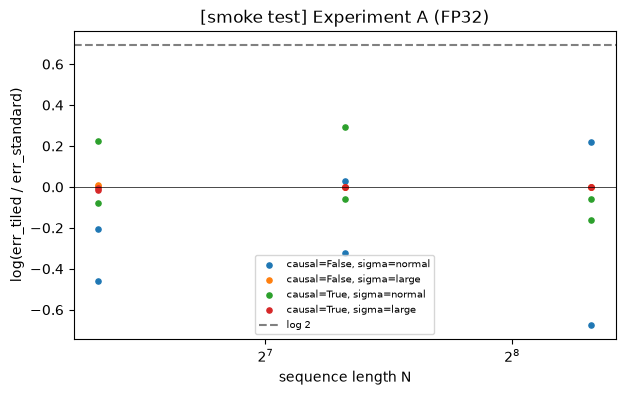

In [9]:
def sample_seed(
    experiment_offset: int, n_index: int, causal: bool, sigma_name: str, replicate: int
) -> int:
    # 系列長・因果マスク・スケール・シードの組ごとに異なるシード(条件間で入力を共有しない)
    condition = (n_index * len(CAUSAL_AB) + CAUSAL_AB.index(causal)) * len(SIGMAS_AB) + list(
        SIGMAS_AB
    ).index(sigma_name)
    return experiment_offset + 1000 * condition + replicate


def log_ratios(err_tiled: np.ndarray, err_standard: np.ndarray) -> np.ndarray:
    # タイリングの誤差が非有限値の標本は +inf とする(6.1 節)
    with np.errstate(divide="ignore", invalid="ignore"):
        values = np.log(err_tiled / err_standard)
    return np.where(np.isfinite(err_tiled), values, np.inf)


def mean_and_standard_error(values: np.ndarray) -> tuple[float, float]:
    return float(values.mean()), float(values.std(ddof=1) / math.sqrt(len(values)))


def ratio_verdict(values: np.ndarray) -> tuple[str, float, float]:
    if not np.all(np.isfinite(values)):
        return "反証", float("inf"), float("nan")
    mean, se = mean_and_standard_error(values)
    if mean + 2 * se < LOG2:
        return "支持", mean, se
    if mean - 2 * se > LOG2:
        return "反証", mean, se
    return "判定不能", mean, se


def verdict_label(computed: str, preconditions: list[str]) -> str:
    return computed if all(precondition_status.get(p) for p in preconditions) else "前提不成立"


records_a = []
_t0 = time.time()
for _i_n, _n in enumerate(SEQUENCE_LENGTHS_AB):
    for _causal in CAUSAL_AB:
        for _sigma_name, _sigma in SIGMAS_AB.items():
            for _r in SEEDS_AB:
                _seed = sample_seed(0, _i_n, _causal, _sigma_name, _r)
                _rec = run_sample_a(_n, _causal, _sigma, _seed)
                _rec.update(n=_n, causal=_causal, sigma=_sigma_name, seed=_seed)
                records_a.append(_rec)
print(f"実験 A: {len(records_a)} 標本、{time.time() - _t0:.1f}s")
assert len({r["seed"] for r in records_a}) == len(records_a), "条件間でシードが重複している"

_err_t_a = np.array([r["err_tiled"] for r in records_a])
_err_s_a = np.array([r["err_standard"] for r in records_a])
precondition_status["P-A"] = bool(np.all(np.isfinite(_err_s_a)) and np.all(_err_s_a > 0))
R_A = log_ratios(_err_t_a, _err_s_a)
verdict_A, RBAR_A, SE_A = ratio_verdict(R_A)
print(
    f"前提条件 P-A(標準の実装の誤差が全標本で有限かつ正): {'成立' if precondition_status['P-A'] else '不成立'}"
)
print(
    f"{_smoke_tag}r_bar = {RBAR_A:+.4f}, SE = {SE_A:.4f}, "
    f"[r_bar - 2SE, r_bar + 2SE] = [{RBAR_A - 2 * SE_A:+.4f}, {RBAR_A + 2 * SE_A:+.4f}], log 2 = {LOG2:.4f}"
    f" -> 判定関数の結果: {verdict_A}"
)

# --- 診断量 ---
print("\n条件ごとの r_bar(FP32)と FP16 の入力での r_bar、誤差の中央値:")
print(
    f"{'causal':>6} | {'sigma':>6} | {'r_bar FP32':>10} | {'r_bar FP16':>10} | {'err_tiled 中央値':>16} | {'err_standard 中央値':>18}"
)
for _causal in CAUSAL_AB:
    for _sigma_name in SIGMAS_AB:
        _sel = [r for r in records_a if r["causal"] == _causal and r["sigma"] == _sigma_name]
        _r32 = log_ratios(
            np.array([r["err_tiled"] for r in _sel]), np.array([r["err_standard"] for r in _sel])
        )
        _r16 = log_ratios(
            np.array([r["err_tiled_fp16"] for r in _sel]),
            np.array([r["err_standard_fp16"] for r in _sel]),
        )
        print(
            f"{str(_causal):>6} | {_sigma_name:>6} | {_r32.mean():>+10.4f} | {_r16.mean():>+10.4f} | "
            f"{np.median([r['err_tiled'] for r in _sel]):>16.3e} | {np.median([r['err_standard'] for r in _sel]):>18.3e}"
        )
_r16_all = log_ratios(
    np.array([r["err_tiled_fp16"] for r in records_a]),
    np.array([r["err_standard_fp16"] for r in records_a]),
)
print(
    f"FP16 の入力での r_bar(全標本) = {_r16_all.mean():+.4f}, SE = {_r16_all.std(ddof=1) / math.sqrt(len(_r16_all)):.4f}"
)
for _sigma_name in SIGMAS_AB:
    _frac = [r["naive_nonfinite_row_fraction"] for r in records_a if r["sigma"] == _sigma_name]
    print(
        f"最大値を引かない素朴な softmax(FP32)で非有限値を含む行の割合(sigma={_sigma_name}): "
        f"平均 {np.mean(_frac):.4f}、最大 {np.max(_frac):.4f}"
    )
for _n in SEQUENCE_LENGTHS_AB:
    _p, _tot = count_block_pairs(_n, _n, *BLOCK_AB, True)
    print(
        f"因果マスクで飛ばしたブロックの割合(N={_n}, B_r=B_c={BLOCK_AB[0]}): {1 - _p / _tot:.3f}({_p}/{_tot} を計算)"
    )

fig, ax = plt.subplots(figsize=(7, 4))
for _causal in CAUSAL_AB:
    for _sigma_name in SIGMAS_AB:
        _sel = [
            (r["n"], math.log(r["err_tiled"] / r["err_standard"]))
            for r in records_a
            if r["causal"] == _causal and r["sigma"] == _sigma_name
        ]
        ax.scatter(
            [x for x, _ in _sel],
            [y for _, y in _sel],
            s=14,
            label=f"causal={_causal}, sigma={_sigma_name}",
        )
ax.axhline(LOG2, color="gray", linestyle="--", label="log 2")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xscale("log", base=2)
ax.set_xlabel("sequence length N")
ax.set_ylabel("log(err_tiled / err_standard)")
ax.set_title(f"{_plot_tag}Experiment A (FP32)")
ax.legend(fontsize=7)
plt.show()

### 6.4 実験 B: 再計算による逆伝播の数値的な一致

In [10]:
records_b = []
_t0 = time.time()
for _i_n, _n in enumerate(SEQUENCE_LENGTHS_AB):
    for _causal in CAUSAL_AB:
        for _sigma_name, _sigma in SIGMAS_AB.items():
            for _r in SEEDS_AB:
                _seed = sample_seed(1_000_000, _i_n, _causal, _sigma_name, _r)
                _rec = run_sample_b(_n, _causal, _sigma, _seed)
                _rec.update(n=_n, causal=_causal, sigma=_sigma_name, seed=_seed)
                records_b.append(_rec)
print(f"実験 B: {len(records_b)} 標本、{time.time() - _t0:.1f}s")
assert len({r["seed"] for r in records_b}) == len(records_b)

_err_t_b = np.array([r["err_tiled"] for r in records_b])  # (標本, 3)
_err_s_b = np.array([r["err_standard"] for r in records_b])
precondition_status["P-B"] = bool(np.all(np.isfinite(_err_s_b)) and np.all(_err_s_b > 0))
_r_bg = log_ratios(_err_t_b, _err_s_b)  # (標本, 3)
R_B = _r_bg.max(axis=1)
verdict_B, RBAR_B, SE_B = ratio_verdict(R_B)
print(
    f"前提条件 P-B(標準の実装の誤差が全標本・全勾配で有限かつ正): {'成立' if precondition_status['P-B'] else '不成立'}"
)
print(
    f"{_smoke_tag}r_bar = {RBAR_B:+.4f}, SE = {SE_B:.4f}, "
    f"[r_bar - 2SE, r_bar + 2SE] = [{RBAR_B - 2 * SE_B:+.4f}, {RBAR_B + 2 * SE_B:+.4f}], log 2 = {LOG2:.4f}"
    f" -> 判定関数の結果: {verdict_B}"
)

# --- 診断量: 勾配ごとの r_bar(極値統計の代わりに平均で捉える)、条件ごとの r_bar ---
for _g, _name in enumerate(GRADIENT_NAMES):
    _m, _se = mean_and_standard_error(_r_bg[:, _g])
    print(
        f"  {_name}: r_bar = {_m:+.4f}(SE {_se:.4f})、err_tiled 中央値 {np.median(_err_t_b[:, _g]):.3e}、"
        f"err_standard 中央値 {np.median(_err_s_b[:, _g]):.3e}"
    )
for _causal in CAUSAL_AB:
    for _sigma_name in SIGMAS_AB:
        _idx = [
            i
            for i, r in enumerate(records_b)
            if r["causal"] == _causal and r["sigma"] == _sigma_name
        ]
        print(
            f"  causal={_causal}, sigma={_sigma_name}: r_bar(3 勾配の最大) = {R_B[_idx].mean():+.4f}"
        )

実験 B: 24 標本、0.1s
前提条件 P-B(標準の実装の誤差が全標本・全勾配で有限かつ正): 成立
[動作確認のみ、結論ではない] r_bar = +0.2259, SE = 0.0442, [r_bar - 2SE, r_bar + 2SE] = [+0.1375, +0.3142], log 2 = 0.6931 -> 判定関数の結果: 支持
  dQ: r_bar = +0.0744(SE 0.0527)、err_tiled 中央値 2.558e-06、err_standard 中央値 2.235e-06
  dK: r_bar = -0.0906(SE 0.0777)、err_tiled 中央値 2.303e-06、err_standard 中央値 2.521e-06
  dV: r_bar = -0.0238(SE 0.0839)、err_tiled 中央値 1.531e-06、err_standard 中央値 1.168e-06
  causal=False, sigma=normal: r_bar(3 勾配の最大) = +0.2050
  causal=False, sigma=large: r_bar(3 勾配の最大) = +0.1704
  causal=True, sigma=normal: r_bar(3 勾配の最大) = +0.2850
  causal=True, sigma=large: r_bar(3 勾配の最大) = +0.2430


### 6.5 実験 C: 順伝播のピークメモリの系列長に対する次数

実験 C: 0.1s、ピークメモリの出典: tracker
前提条件 P-C1(CUDA): 不成立、P-C2(全水準で完走): 成立
     N |          標準の増分 |    閉形式 2BHN^2*4 |      比 |         タイリングの増分 |        閉形式(L + ブロック)
   256 |      2,097,152 |       2,097,152 |  1.000 |        1,191,936 |            1,183,744
   512 |      8,388,608 |       8,388,608 |  1.000 |        1,196,032 |            1,187,840
  1024 |     33,554,432 |      33,554,432 |  1.000 |        1,204,224 |            1,196,032
[動作確認のみ、結論ではない] b_standard = 2.0000(SE 0.0000), b_tiled = 0.0074(SE 0.0014), diff = 1.9926, SE_diff = 0.0014, [diff - 2SE, diff + 2SE] = [1.9898, 1.9954] -> 判定関数の結果: 支持

HBM の読み書き量の理論値(要素数)、B_r = B_c = 128:
  N=   256: 標準 1,310,720、タイリング 394,240(標準に対する比 0.301)
  N=   512: 標準 4,718,592、タイリング 1,312,768(標準に対する比 0.278)
  N=  1024: 標準 17,825,792、タイリング 4,722,688(標準に対する比 0.265)
ブロックの行数の関数(N=1024、B_r = B_c): 16: 1.912, 32: 0.971, 64: 0.500, 128: 0.265, 256: 0.147


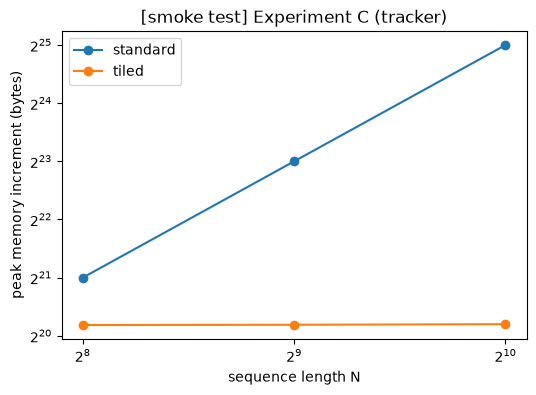

In [11]:
def fit_exponent_difference(ns, standard_values, other_values):
    fit_s = fit_power_law_exponent(ns, standard_values)
    fit_o = fit_power_law_exponent(ns, other_values)
    diff = fit_s.exponent - fit_o.exponent
    se = math.sqrt(fit_s.exponent_stderr**2 + fit_o.exponent_stderr**2)
    return fit_s, fit_o, diff, se


def exponent_verdict(diff: float, se: float) -> str:
    if diff - 2 * se > EXPONENT_DIFF_THRESHOLD:
        return "支持"
    if diff + 2 * se < EXPONENT_DIFF_THRESHOLD:
        return "反証"
    return "判定不能"


MEMORY_SOURCE_C = "cuda_allocator" if device.type == "cuda" else "tracker"
records_c = {"standard": [], "tiled": []}
_t0 = time.time()
for _n in SEQUENCE_LENGTHS_C:
    for _impl in records_c:
        records_c[_impl].append(measure_forward_memory(_impl, _n))
print(f"実験 C: {time.time() - _t0:.1f}s、ピークメモリの出典: {MEMORY_SOURCE_C}")
# 条件間で入力の形状・dtype が揃っていること
for _i, _n in enumerate(SEQUENCE_LENGTHS_C):
    assert (
        records_c["standard"][_i]["shape"]
        == records_c["tiled"][_i]["shape"]
        == [BATCH_C, HEADS_C, _n, HEAD_DIM]
    )
    assert records_c["standard"][_i]["dtype"] == records_c["tiled"][_i]["dtype"] == "torch.float32"

precondition_status["P-C1"] = device.type == "cuda"
precondition_status["P-C2"] = all(r["completed"] for rs in records_c.values() for r in rs)
INCREMENT_C = {
    impl: [peak_increment_bytes(r, MEMORY_SOURCE_C) for r in rs] for impl, rs in records_c.items()
}
print(
    f"前提条件 P-C1(CUDA): {'成立' if precondition_status['P-C1'] else '不成立'}、"
    f"P-C2(全水準で完走): {'成立' if precondition_status['P-C2'] else '不成立'}"
)
print(
    f"{'N':>6} | {'標準の増分':>14} | {'閉形式 2BHN^2*4':>15} | {'比':>6} | {'タイリングの増分':>16} | {'閉形式(L + ブロック)':>20}"
)
for _i, _n in enumerate(SEQUENCE_LENGTHS_C):
    _s, _t = INCREMENT_C["standard"][_i], INCREMENT_C["tiled"][_i]
    _est_s = estimate_standard_peak_bytes_c(_n)
    _est_t = BATCH_C * HEADS_C * (_n * 4 + 3 * BLOCK_C[0] * (BLOCK_C[1] + HEAD_DIM) * 4)
    _s_text = "-" if _s is None else f"{_s:,}"
    _t_text = "-" if _t is None else f"{_t:,}"
    _ratio_text = "-" if _s is None else f"{_s / _est_s:.3f}"
    print(
        f"{_n:>6} | {_s_text:>14} | {_est_s:>15,} | {_ratio_text:>6} | {_t_text:>16} | {_est_t:>20,}"
    )

FIT_C = None
if all(v is not None and v > 0 for vs in INCREMENT_C.values() for v in vs):
    _fs, _ft, DIFF_C, SE_DIFF_C = fit_exponent_difference(
        list(SEQUENCE_LENGTHS_C), INCREMENT_C["standard"], INCREMENT_C["tiled"]
    )
    FIT_C = (_fs, _ft)
    verdict_C = exponent_verdict(DIFF_C, SE_DIFF_C)
    print(
        f"{_smoke_tag}b_standard = {_fs.exponent:.4f}(SE {_fs.exponent_stderr:.4f}), "
        f"b_tiled = {_ft.exponent:.4f}(SE {_ft.exponent_stderr:.4f}), "
        f"diff = {DIFF_C:.4f}, SE_diff = {SE_DIFF_C:.4f}, "
        f"[diff - 2SE, diff + 2SE] = [{DIFF_C - 2 * SE_DIFF_C:.4f}, {DIFF_C + 2 * SE_DIFF_C:.4f}] "
        f"-> 判定関数の結果: {verdict_C}"
    )
else:
    DIFF_C = SE_DIFF_C = float("nan")
    verdict_C = "判定不能(完走しなかった水準があり、あてはめを行わない)"
    print(verdict_C)

# --- 診断量: tracker と CUDA のアロケータの比較(CUDA のみ) ---
if device.type == "cuda":
    for _impl, _rs in records_c.items():
        print(
            f"  {_impl}: tracker の増分 / アロケータの増分 = "
            + ", ".join(
                f"{peak_increment_bytes(r, 'tracker') / peak_increment_bytes(r, 'cuda_allocator'):.3f}"
                if r["completed"]
                else "-"
                for r in _rs
            )
        )
        print(
            f"  {_impl}: 呼び出し直前の確保量 - 入力のバイト数 = "
            + ", ".join(
                f"{r['cuda_baseline_bytes'] - r['input_bytes']:,}" if r["completed"] else "-"
                for r in _rs
            )
        )


# --- 診断量: HBM の読み書き量の理論値(要素数、バッチ x ヘッド分) ---
def tiled_io_elements(n: int, block_q: int, block_k: int, causal: bool = False) -> int:
    # Q を 1 回読み、O と L を 1 回書き、計算するブロックの組ごとに K_j と V_j を読む
    pairs = 0
    for i0 in range(0, n, block_q):
        i1 = min(i0 + block_q, n)
        for j0 in range(0, min(i1, n) if causal else n, block_k):
            pairs += min(j0 + block_k, n) - j0
    return BATCH_C * HEADS_C * (n * HEAD_DIM + n * HEAD_DIM + n + 2 * HEAD_DIM * pairs)


def standard_io_elements(n: int) -> int:
    return BATCH_C * HEADS_C * (4 * n * HEAD_DIM + 4 * n * n)


print("\nHBM の読み書き量の理論値(要素数)、B_r = B_c = 128:")
for _n in SEQUENCE_LENGTHS_C:
    _io_t, _io_s = tiled_io_elements(_n, *BLOCK_C), standard_io_elements(_n)
    print(f"  N={_n:>6}: 標準 {_io_s:,}、タイリング {_io_t:,}(標準に対する比 {_io_t / _io_s:.3f})")
_n_max = max(SEQUENCE_LENGTHS_C)
print(
    f"ブロックの行数の関数(N={_n_max}、B_r = B_c): "
    + ", ".join(
        f"{b}: {tiled_io_elements(_n_max, b, b) / standard_io_elements(_n_max):.3f}"
        for b in (16, 32, 64, 128, 256)
    )
)

fig, ax = plt.subplots(figsize=(6, 4))
for _impl in INCREMENT_C:
    _pts = [(n, v) for n, v in zip(SEQUENCE_LENGTHS_C, INCREMENT_C[_impl], strict=False) if v]
    ax.loglog([p[0] for p in _pts], [p[1] for p in _pts], "o-", base=2, label=_impl)
ax.set_xlabel("sequence length N")
ax.set_ylabel("peak memory increment (bytes)")
ax.set_title(f"{_plot_tag}Experiment C ({MEMORY_SOURCE_C})")
ax.legend()
plt.show()

### 6.6 実験 D: 逆伝播のために保存する活性化の系列長に対する次数

実験 D: 0.1s
[動作確認のみ、結論ではない] b_standard = 1.8349(SE 0.0268), b_flash = 1.0000(SE 0.0000), diff = 0.8349, SE_diff = 0.0268, [diff - 2SE, diff + 2SE] = [0.7813, 0.8885] -> 判定関数の結果: 支持
     N |         標準(実測) |   4BH(3Nd+N^2) |    Flash(実測) |   4BH(4Nd+N) | 保存した記憶領域の数(標準 / Flash)
   512 |      5,767,168 |      5,767,168 |    2,105,344 |    2,105,344 | 4 / 5
  1024 |     19,922,944 |     19,922,944 |    4,210,688 |    4,210,688 | 4 / 5
  2048 |     73,400,320 |     73,400,320 |    8,421,376 |    8,421,376 | 4 / 5
閉形式 4BH(3Nd+N^2) を同じ水準であてはめたべき指数: 1.8349


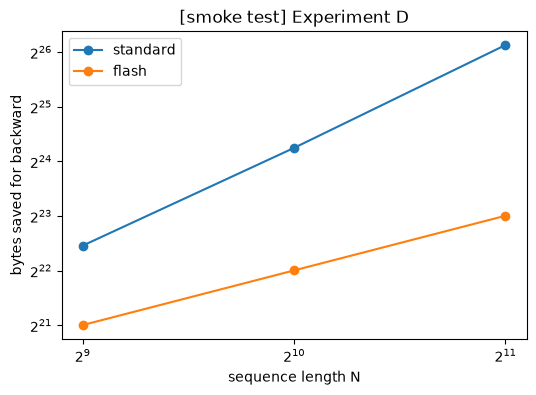

In [12]:
records_d = {"standard": [], "flash": []}
_t0 = time.time()
for _n in SEQUENCE_LENGTHS_D:
    records_d["standard"].append(measure_saved_tensor_bytes("standard", _n))
    records_d["flash"].append(measure_saved_tensor_bytes("tiled", _n))
print(f"実験 D: {time.time() - _t0:.1f}s")
for _i, _n in enumerate(SEQUENCE_LENGTHS_D):
    assert (
        records_d["standard"][_i]["shape"]
        == records_d["flash"][_i]["shape"]
        == [BATCH_D, HEADS_D, _n, HEAD_DIM]
    )
    assert records_d["flash"][_i]["num_saved_storages"] == 5, (
        "FlashAttentionFunction が Q, K, V, O, L 以外を保存した"
    )

SAVED_D = {impl: [r["saved_bytes"] for r in rs] for impl, rs in records_d.items()}
_fs, _ff, DIFF_D, SE_DIFF_D = fit_exponent_difference(
    list(SEQUENCE_LENGTHS_D), SAVED_D["standard"], SAVED_D["flash"]
)
verdict_D = exponent_verdict(DIFF_D, SE_DIFF_D)
print(
    f"{_smoke_tag}b_standard = {_fs.exponent:.4f}(SE {_fs.exponent_stderr:.4f}), "
    f"b_flash = {_ff.exponent:.4f}(SE {_ff.exponent_stderr:.4f}), diff = {DIFF_D:.4f}, SE_diff = {SE_DIFF_D:.4f}, "
    f"[diff - 2SE, diff + 2SE] = [{DIFF_D - 2 * SE_DIFF_D:.4f}, {DIFF_D + 2 * SE_DIFF_D:.4f}] "
    f"-> 判定関数の結果: {verdict_D}"
)

# --- 診断量: 閉形式との比較、逆伝播の時間の比(CUDA のみ) ---
_bh = BATCH_D * HEADS_D
print(
    f"{'N':>6} | {'標準(実測)':>14} | {'4BH(3Nd+N^2)':>14} | {'Flash(実測)':>12} | {'4BH(4Nd+N)':>12} | 保存した記憶領域の数(標準 / Flash)"
)
for _i, _n in enumerate(SEQUENCE_LENGTHS_D):
    print(
        f"{_n:>6} | {SAVED_D['standard'][_i]:>14,} | {4 * _bh * (3 * _n * HEAD_DIM + _n * _n):>14,} | "
        f"{SAVED_D['flash'][_i]:>12,} | {4 * _bh * (4 * _n * HEAD_DIM + _n):>12,} | "
        f"{records_d['standard'][_i]['num_saved_storages']} / {records_d['flash'][_i]['num_saved_storages']}"
    )
_closed = fit_power_law_exponent(
    list(SEQUENCE_LENGTHS_D), [4 * _bh * (3 * n * HEAD_DIM + n * n) for n in SEQUENCE_LENGTHS_D]
)
print(f"閉形式 4BH(3Nd+N^2) を同じ水準であてはめたべき指数: {_closed.exponent:.4f}")
if device.type == "cuda":
    print(
        "逆伝播の時間の比(FlashAttentionFunction / 標準、Python のループのオーバーヘッドを含む): "
        + ", ".join(
            f"N={n}: {f['backward_seconds_median'] / s['backward_seconds_median']:.2f}"
            for n, s, f in zip(SEQUENCE_LENGTHS_D, records_d["standard"], records_d["flash"], strict=False)
        )
    )

fig, ax = plt.subplots(figsize=(6, 4))
for _impl, _vals in SAVED_D.items():
    ax.loglog(SEQUENCE_LENGTHS_D, _vals, "o-", base=2, label=_impl)
ax.set_xlabel("sequence length N")
ax.set_ylabel("bytes saved for backward")
ax.set_title(f"{_plot_tag}Experiment D")
ax.legend()
plt.show()

### 6.7 実験 E: 読み書き量の削減による速度の系列長依存性(SDPA のバックエンドの比較)

実験 E: 0.1s、バックエンド: math=MATH, fused=FLASH_ATTENTION、dtype: torch.float32
前提条件 P-E1(CUDA): 不成立、P-E2(指定したバックエンドで実行): 成立
  N=128: 実行された演算 {'math': ['aten::_scaled_dot_product_attention_math'], 'fused': ['aten::_scaled_dot_product_flash_attention_for_cpu']}
  N=256: 実行された演算 {'math': ['aten::_scaled_dot_product_attention_math'], 'fused': ['aten::_scaled_dot_product_flash_attention_for_cpu']}
  N=512: 実行された演算 {'math': ['aten::_scaled_dot_product_attention_math'], 'fused': ['aten::_scaled_dot_product_flash_attention_for_cpu']}
[動作確認のみ、結論ではない] beta = -0.0643, SE = 0.0338, [beta - 2SE, beta + 2SE] = [-0.1320, +0.0034] -> 判定関数の結果: 判定不能

     N |    math 中央値 (ms) |    fused 中央値 (ms) |      比の中央値 |     スクラッチ (ms)
   128 |            0.218 |             0.080 |      2.734 |            0.3
   256 |            0.461 |             0.194 |      2.435 |            1.0
   512 |            1.504 |             0.616 |      2.474 |            3.6
(スクラッチ実装の時間は Python のループによるもので、Flash Attention の本来の性能を反映しない)


USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:59] profiler_stop
USDT:2026-09-25 06:45:13 97838:9813497 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-25

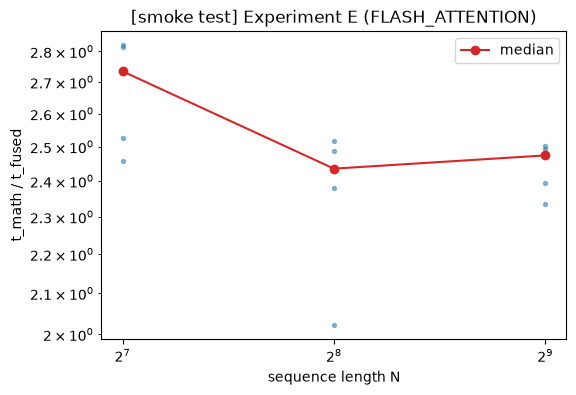

In [13]:
records_e = []
_t0 = time.time()
for _n in SEQUENCE_LENGTHS_E:
    records_e.append(run_level_e(_n, REPETITIONS_E))
print(
    f"実験 E: {time.time() - _t0:.1f}s、バックエンド: "
    + ", ".join(f"{k}={v.name}" for k, v in SDPA_BACKENDS_E.items())
    + f"、dtype: {DTYPE_E}"
)
for _i, _n in enumerate(SEQUENCE_LENGTHS_E):  # 条件間で入力の形状・dtype が揃っていること
    assert records_e[_i]["shape"] == [BATCH_E, HEADS_E, _n, HEAD_DIM] and records_e[_i][
        "dtype"
    ] == str(DTYPE_E)
    assert all(len(records_e[_i]["times"][name]) == REPETITIONS_E for name in SDPA_BACKENDS_E)

precondition_status["P-E1"] = device.type == "cuda"
precondition_status["P-E2"] = all(
    r["ops"][name] == [EXPECTED_SDPA_OPS[name]] for r in records_e for name in SDPA_BACKENDS_E
)
print(
    f"前提条件 P-E1(CUDA): {'成立' if precondition_status['P-E1'] else '不成立'}、"
    f"P-E2(指定したバックエンドで実行): {'成立' if precondition_status['P-E2'] else '不成立'}"
)
for _n, _r in zip(SEQUENCE_LENGTHS_E, records_e, strict=False):
    print(f"  N={_n}: 実行された演算 {_r['ops']}")


def slope_of_log_ratio(ns, records) -> tuple[float, float]:
    xs, ys = [], []
    for n, r in zip(ns, records, strict=False):
        for t_math, t_fused in zip(r["times"]["math"], r["times"]["fused"], strict=False):
            xs.append(n)
            ys.append(t_math / t_fused)
    fit = fit_power_law_exponent(xs, ys)  # log(ratio) = c + beta log N
    return fit.exponent, fit.exponent_stderr


BETA_E, SE_BETA_E = slope_of_log_ratio(SEQUENCE_LENGTHS_E, records_e)
if BETA_E - 2 * SE_BETA_E > 0:
    verdict_E = "支持"
elif BETA_E + 2 * SE_BETA_E < 0:
    verdict_E = "反証"
else:
    verdict_E = "判定不能"
print(
    f"{_smoke_tag}beta = {BETA_E:+.4f}, SE = {SE_BETA_E:.4f}, "
    f"[beta - 2SE, beta + 2SE] = [{BETA_E - 2 * SE_BETA_E:+.4f}, {BETA_E + 2 * SE_BETA_E:+.4f}] -> 判定関数の結果: {verdict_E}"
)

print(
    f"\n{'N':>6} | {'math 中央値 (ms)':>16} | {'fused 中央値 (ms)':>17} | {'比の中央値':>10} | {'スクラッチ (ms)':>14}"
)
for _n, _r in zip(SEQUENCE_LENGTHS_E, records_e, strict=False):
    _ratios = np.array(_r["times"]["math"]) / np.array(_r["times"]["fused"])
    print(
        f"{_n:>6} | {np.median(_r['times']['math']) * 1e3:>16.3f} | {np.median(_r['times']['fused']) * 1e3:>17.3f} | "
        f"{np.median(_ratios):>10.3f} | {_r['scratch_seconds'] * 1e3:>14.1f}"
    )
    if "cuda_peak_increment_bytes" in _r:
        print(
            "         ピークメモリの増分: "
            + ", ".join(f"{k} {v:,}" for k, v in _r["cuda_peak_increment_bytes"].items())
        )
print(
    "(スクラッチ実装の時間は Python のループによるもので、Flash Attention の本来の性能を反映しない)"
)

fig, ax = plt.subplots(figsize=(6, 4))
for _n, _r in zip(SEQUENCE_LENGTHS_E, records_e, strict=False):
    _ratios = np.array(_r["times"]["math"]) / np.array(_r["times"]["fused"])
    ax.scatter([_n] * len(_ratios), _ratios, s=8, color="tab:blue", alpha=0.5)
ax.plot(
    SEQUENCE_LENGTHS_E,
    [np.median(np.array(r["times"]["math"]) / np.array(r["times"]["fused"])) for r in records_e],
    "o-",
    color="tab:red",
    label="median",
)
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("sequence length N")
ax.set_ylabel("t_math / t_fused")
ax.set_title(f"{_plot_tag}Experiment E ({SDPA_BACKENDS_E['fused'].name})")
ax.legend()
plt.show()

### 6.8 判定の一次情報(全件)

判定の一次情報(事前宣言した判定基準の対比量と前提条件を再計算できる最小の量)を全件印字する。

- `experiment_A`: 標本ごとの系列長・因果マスクの有無・スケール・シード・$\mathrm{err}_{\mathrm{tiled}}$・$\mathrm{err}_{\mathrm{standard}}$(FP32)。
- `experiment_B`: 標本ごとの同じ条件の列と、勾配ごとの $\mathrm{err}_{\mathrm{tiled}}$・$\mathrm{err}_{\mathrm{standard}}$。
- `experiment_C`: 水準ごとの完走の有無と、ピークメモリの増分を求めるための生の値(CUDA: ピーク・呼び出し直前の確保量・出力のバイト数、
  tracker: ピーク・出力のバイト数)。ピークメモリの出典。
- `experiment_D`: 水準ごとの保存バイト数。
- `experiment_E`: 水準ごとの反復ごとの時間(両バックエンド)と、実行された演算の名前。
- `preconditions`: デバイスの種類(P-C1・P-E1)。

FP16 の誤差・素朴な softmax・閉形式・読み書き量の理論値・逆伝播の時間・スクラッチ実装の時間などの診断量は、判定に使わないので
含めない(6.3〜6.7 節で印字している)。

**一次情報だけからの再計算**: 印字した文字列を JSON として読み戻したデータのみを使って、前提条件と全実験の対比量を再計算し、
判定に使った値と一致することをアサーションで確かめる。

In [14]:
def _columns(records, keys):
    return {key: [r[key] for r in records] for key in keys}


primary_data = {
    "smoke_test": SMOKE_TEST,
    "device_type": device.type,
    "experiment_A": _columns(
        records_a, ("n", "causal", "sigma", "seed", "err_tiled", "err_standard")
    ),
    "experiment_B": {
        **_columns(records_b, ("n", "causal", "sigma", "seed")),
        "err_tiled": {
            g: [r["err_tiled"][i] for r in records_b] for i, g in enumerate(GRADIENT_NAMES)
        },
        "err_standard": {
            g: [r["err_standard"][i] for r in records_b] for i, g in enumerate(GRADIENT_NAMES)
        },
    },
    "experiment_C": {
        "sequence_lengths": list(SEQUENCE_LENGTHS_C),
        "memory_source": MEMORY_SOURCE_C,
        **{
            impl: {
                "completed": [r["completed"] for r in rs],
                "output_bytes": [r.get("output_bytes") for r in rs],
                "tracker_peak_bytes": [r.get("tracker_peak_bytes") for r in rs],
                **(
                    {
                        "cuda_peak_bytes": [r.get("cuda_peak_bytes") for r in rs],
                        "cuda_baseline_bytes": [r.get("cuda_baseline_bytes") for r in rs],
                    }
                    if device.type == "cuda"
                    else {}
                ),
            }
            for impl, rs in records_c.items()
        },
    },
    "experiment_D": {
        "sequence_lengths": list(SEQUENCE_LENGTHS_D),
        **{f"{k}_saved_bytes": v for k, v in SAVED_D.items()},
    },
    "experiment_E": {
        "sequence_lengths": list(SEQUENCE_LENGTHS_E),
        "backends": {k: v.name for k, v in SDPA_BACKENDS_E.items()},
        "t_math_seconds": [r["times"]["math"] for r in records_e],
        "t_fused_seconds": [r["times"]["fused"] for r in records_e],
        "executed_ops": [r["ops"] for r in records_e],
    },
}

PRIMARY_DATA_TEXT = dumps_compact_json(primary_data)
print(PRIMARY_DATA_TEXT)
assert json.loads(PRIMARY_DATA_TEXT) == primary_data, "整形で情報が落ちた"
_long_lines = [len(line) for line in PRIMARY_DATA_TEXT.splitlines() if len(line) > 100]
assert not _long_lines, f"100 文字を超える行がある: {_long_lines[:10]}"
print(
    f"\n判定の一次情報の出力: {len(PRIMARY_DATA_TEXT.splitlines()):,} 行・{len(PRIMARY_DATA_TEXT):,} 文字"
)


# --- 一次情報だけからの再計算(印字した文字列を読み戻したデータのみを使う) ---
def _close(a: float, b: float) -> bool:
    return (math.isnan(a) and math.isnan(b)) or math.isclose(a, b, rel_tol=1e-9, abs_tol=1e-12)


_loaded = json.loads(PRIMARY_DATA_TEXT)
_la = _loaded["experiment_A"]
_ra = log_ratios(np.array(_la["err_tiled"]), np.array(_la["err_standard"]))
_v, _m, _se = ratio_verdict(_ra)
assert _v == verdict_A and _close(_m, RBAR_A) and _close(_se, SE_A)
assert (
    np.all(np.isfinite(_la["err_standard"])) and min(_la["err_standard"]) > 0
) == precondition_status["P-A"]

_lb = _loaded["experiment_B"]
_et = np.array([_lb["err_tiled"][g] for g in GRADIENT_NAMES]).T
_es = np.array([_lb["err_standard"][g] for g in GRADIENT_NAMES]).T
_v, _m, _se = ratio_verdict(log_ratios(_et, _es).max(axis=1))
assert _v == verdict_B and _close(_m, RBAR_B) and _close(_se, SE_B)
assert (np.all(np.isfinite(_es)) and _es.min() > 0) == precondition_status["P-B"]

_lc = _loaded["experiment_C"]
assert (
    (_loaded["device_type"] == "cuda") == precondition_status["P-C1"] == precondition_status["P-E1"]
)
assert all(all(_lc[i]["completed"]) for i in ("standard", "tiled")) == precondition_status["P-C2"]
_inc = {}
for _impl in ("standard", "tiled"):
    _d = _lc[_impl]
    if _lc["memory_source"] == "cuda_allocator":
        _inc[_impl] = [
            p - b - o if c else None
            for p, b, o, c in zip(
                _d["cuda_peak_bytes"],
                _d["cuda_baseline_bytes"],
                _d["output_bytes"],
                _d["completed"], strict=False,
            )
        ]
    else:
        _inc[_impl] = [
            p - o if c else None
            for p, o, c in zip(_d["tracker_peak_bytes"], _d["output_bytes"], _d["completed"], strict=False)
        ]
    assert _inc[_impl] == INCREMENT_C[_impl]
if FIT_C is not None:
    _, _, _diff, _se = fit_exponent_difference(
        _lc["sequence_lengths"], _inc["standard"], _inc["tiled"]
    )
    assert (
        _close(_diff, DIFF_C)
        and _close(_se, SE_DIFF_C)
        and exponent_verdict(_diff, _se) == verdict_C
    )

_ld = _loaded["experiment_D"]
_, _, _diff, _se = fit_exponent_difference(
    _ld["sequence_lengths"], _ld["standard_saved_bytes"], _ld["flash_saved_bytes"]
)
assert (
    _close(_diff, DIFF_D) and _close(_se, SE_DIFF_D) and exponent_verdict(_diff, _se) == verdict_D
)

_le = _loaded["experiment_E"]
_beta, _se = slope_of_log_ratio(
    _le["sequence_lengths"],
    [
        {"times": {"math": m, "fused": f}}
        for m, f in zip(_le["t_math_seconds"], _le["t_fused_seconds"], strict=False)
    ],
)
assert _close(_beta, BETA_E) and _close(_se, SE_BETA_E)
assert (
    all(
        ops[name] == [EXPECTED_SDPA_OPS[name]]
        for ops in _le["executed_ops"]
        for name in ("math", "fused")
    )
    == precondition_status["P-E2"]
)
print("一次情報だけからの再計算: 前提条件と全実験の対比量・判定が一致(OK)")

{
  "smoke_test": true,
  "device_type": "cpu",
  "experiment_A": {
    "n": [
      80, 80, 80, 80, 80, 80, 80, 80, 160, 160, 160, 160, 160, 160, 160, 160, 320, 320, 320, 320,
      320, 320, 320, 320
    ],
    "causal": [
      false, false, false, false, true, true, true, true, false, false, false, false, true, true,
      true, true, false, false, false, false, true, true, true, true
    ],
    "sigma": [
      "normal", "normal", "large", "large", "normal", "normal", "large", "large", "normal",
      "normal", "large", "large", "normal", "normal", "large", "large", "normal", "normal", "large",
      "large", "normal", "normal", "large", "large"
    ],
    "seed": [
      0, 1, 1000, 1001, 2000, 2001, 3000, 3001, 4000, 4001, 5000, 5001, 6000, 6001, 7000, 7001,
      8000, 8001, 9000, 9001, 10000, 10001, 11000, 11001
    ],
    "err_tiled": [
      6.240316063551031e-07, 4.387711350339992e-07, 4.74817951861965e-06, 3.026433661431953e-06,
      1.2847223104628376e-07, 5.047921555575

### 6.9 判定結果の一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは区別する)。判定関数の結果は
参考として別欄に残す。あわせて、`SMOKE_TEST`の水準が実際に使われた値と一致することを確かめる。

In [15]:
# SMOKE_TEST の配線: 実際に使われた水準・シード数・反復回数の照合
assert (
    tuple(sorted({r["n"] for r in records_a}))
    == SEQUENCE_LENGTHS_AB
    == tuple(sorted({r["n"] for r in records_b}))
)
assert (
    len(records_a)
    == len(records_b)
    == len(SEQUENCE_LENGTHS_AB) * len(CAUSAL_AB) * len(SIGMAS_AB) * NUM_SEEDS_AB
)
assert all(len(rs) == len(SEQUENCE_LENGTHS_C) for rs in records_c.values())
assert all(len(rs) == len(SEQUENCE_LENGTHS_D) for rs in records_d.values())
assert len(records_e) == len(SEQUENCE_LENGTHS_E)
assert all(len(r["times"][name]) == REPETITIONS_E for r in records_e for name in SDPA_BACKENDS_E)
print(
    f"SMOKE_TEST の配線: 水準({CURRENT_LEVEL_NAME!r})・シード数 {NUM_SEEDS_AB}・反復 {REPETITIONS_E} が実効水準と一致: OK"
)

_experiment_preconditions = {
    "A": ["P-A"],
    "B": ["P-B"],
    "C": ["P-C1", "P-C2"],
    "D": [],
    "E": ["P-E1", "P-E2"],
}
_verdicts = [
    ("A", f"r_bar={RBAR_A:+.4f}、SE={SE_A:.4f}", verdict_A),
    ("B", f"r_bar={RBAR_B:+.4f}、SE={SE_B:.4f}", verdict_B),
    ("C", f"diff={DIFF_C:.4f}、SE={SE_DIFF_C:.4f}", verdict_C),
    ("D", f"diff={DIFF_D:.4f}、SE={SE_DIFF_D:.4f}", verdict_D),
    ("E", f"beta={BETA_E:+.4f}、SE={SE_BETA_E:.4f}", verdict_E),
]
print(f"\n{_smoke_tag}実験 | 対比量 | 前提条件の成否 | 判定関数の結果(参考) | 最終判定")
for _name, _stat, _computed in _verdicts:
    _pre = (
        ", ".join(f"{p}={precondition_status.get(p)}" for p in _experiment_preconditions[_name])
        or "なし"
    )
    print(
        f"{_smoke_tag}{_name} | {_stat} | {_pre} | {_computed} | "
        f"{verdict_label(_computed, _experiment_preconditions[_name])}"
    )

SMOKE_TEST の配線: 水準('smoke')・シード数 2・反復 5 が実効水準と一致: OK

[動作確認のみ、結論ではない] 実験 | 対比量 | 前提条件の成否 | 判定関数の結果(参考) | 最終判定
[動作確認のみ、結論ではない] A | r_bar=-0.0531、SE=0.0420 | P-A=True | 支持 | 支持
[動作確認のみ、結論ではない] B | r_bar=+0.2259、SE=0.0442 | P-B=True | 支持 | 支持
[動作確認のみ、結論ではない] C | diff=1.9926、SE=0.0014 | P-C1=False, P-C2=True | 支持 | 前提不成立
[動作確認のみ、結論ではない] D | diff=0.8349、SE=0.0268 | なし | 支持 | 支持
[動作確認のみ、結論ではない] E | beta=-0.0643、SE=0.0338 | P-E1=False, P-E2=True | 判定不能 | 前提不成立


## 7. 結果・考察 / Results and Discussion

**この節は本番実行(Google Colab T4、`SMOKE_TEST=False`)の後に、セル出力と突き合わせて書く。** 現時点では見出しと、
何を書くかのみを置く。判定は 6.1 節で事前に宣言した基準のみから導き、結果を見た後に立てた解釈は「事後的な解釈」として
節または段落を分けて記す。

**本番実行の後に更新が必要な箇所**:

- 7.1〜7.7 節の本文(下の箇条書きを本文に置き換える)。
- 実行環境の記述(5.1 節の`print_execution_environment()`の印字を出典とする)。
- 6.2 節の見積もりと、本番の実際の所要時間の比較。
- `theories/README.md`の 014 の行の末尾(「第 1 段階(スモークテスト)まで完了、本番実行前」を結果の要約に置き換える)。

### 7.1 実行環境と前提条件の成否

- 5.1 節の印字(GPU 名・compute capability・torch と CUDA のバージョン・コミット)。
- 前提条件 P-A・P-B・P-C1・P-C2・P-E1・P-E2 の成否の表(評価に使った量と閾値)。
- 5.5 節で flash バックエンドが T4 で例外になったこと(印字された例外のメッセージ)。

### 7.2 実験 A(順伝播の数値的な一致)の判定結果

- 判定と $\bar{r}$・SE・区間。
- 診断量: 条件ごとの $\bar{r}$、FP16 の入力での $\bar{r}$、素朴な softmax の非有限値の割合、因果マスクで飛ばしたブロックの割合。

### 7.3 実験 B(再計算による逆伝播の数値的な一致)の判定結果

- 判定と $\bar{r}$・SE・区間。
- 診断量: 勾配ごとの $\bar{r}_g$、条件ごとの $\bar{r}$。

### 7.4 実験 C(順伝播のピークメモリの次数)の判定結果

- 判定と $b_{\mathrm{standard}}$・$b_{\mathrm{tiled}}$・$\Delta b$・SE。
- 診断量: 閉形式との比、tracker とアロケータの比、読み書き量の理論値。

### 7.5 実験 D(逆伝播のために保存する活性化の次数)の判定結果

- 判定と $b_{\mathrm{standard}}$・$b_{\mathrm{flash}}$・$\Delta b$・SE。
- 診断量: 閉形式との一致、逆伝播の時間の比。

### 7.6 実験 E(SDPA のバックエンドの速度比の系列長依存性)の判定結果

- 判定と $\beta$・SE・区間。前提条件 P-E2(実行された演算の名前)。
- 診断量: 水準ごとの時間の中央値と比、スクラッチ実装の時間(本来の性能を反映しないこと)、ピークメモリ。

### 7.7 まとめ

- 5 つの実験の判定の一覧と、事前宣言した基準から言えること・言えないこと。
- 事後的な解釈(あれば、検証済みの結論と分けて)。